# Can we learn to avoid the vaults that lose money?

Six ways of acting on [NB78](78-research-curve-shape-and-ensemble-scoring.ipynb)'s finding that the
vaults responsible for most losses share a property the selection score cannot see: they almost
never post a down day. **Objective is Sharpe throughout.**

**Based on** [75-candidate-backtest-inverse-variance-45d-33pct.ipynb](75-candidate-backtest-inverse-variance-45d-33pct.ipynb) -
45-day `inverse_variance`, 6 vaults, 33% concentration, 25% pool cap, 150,000 - with veto machinery
added. With the veto disabled the notebook reproduces that candidate exactly, which is what the
baseline row checks.

## Why vetoes rather than a better score

NB78 tried to fix selection by changing the score, using an ensemble of lookbacks. It failed
instructively: both ensemble variants **did** avoid the named blow-ups - one turned Citadel from a
-$2,128 loss into a +$2,419 profit - and both performed dramatically worse overall, because
re-ranking the universe changed what got bought *instead*, and the replacements were worse.

A veto cannot do that. It removes candidates and leaves the ordering of everything else untouched,
so its damage is bounded and countable. Five of the six variants here are therefore vetoes. The
sixth replaces the Sharpe leg with Sortino, which is the one re-ranking worth trying because NB78
measured the Sharpe leg as separating losers from winners at **0.038** - no better than chance -
while downside-based features reached 0.317.

## Guards against fooling ourselves

- **No veto fires on fewer than 30 observations.** A downside deviation of zero measured on six
  weekly prints is absence of *data*, not absence of *risk*, and the feed is weekly before
  2026-01-17.
- **An unmeasurable statistic does not veto.** Otherwise every veto silently becomes an age filter;
  age is tested separately as V5.
- **Plateau, not peak.** A variant is only believed if several adjacent thresholds beat the
  baseline. NB77's momentum-gate optimum was a spike with neighbours 10-22 pp worse, and that is
  the pattern to avoid repeating.
- **The cost is reported.** Every run states how many vaults it dropped versus baseline and how
  much baseline *profit* went with them. NB78's failure was invisible in headline metrics.

## Key new insights and what did we learn from this experiment?

### Every veto failed. All five families, eighteen of nineteen thresholds

Baseline Sharpe is **1.549**.

| Family | Thresholds | Beating baseline | Best Sharpe | Median delta |
|---|---:|---:|---:|---:|
| V1 downside share | 5 | **0** | 1.265 | -0.608 |
| V2 down-day share | 5 | **0** | 1.530 | -1.130 |
| V3 lag-1 autocorrelation | 4 | **0** | 1.148 | -0.776 |
| V5 history days | 4 | **0** | 1.549 | 0.000 |
| V4 skew | 4 | 1 | 1.751 | -1.152 |

The single exception, `skew > 1.0` at Sharpe 1.751, is surrounded by 1.5, 2.0 and 3.0 scoring
-0.222, -0.099 and 0.893. That is the spike pattern this notebook was built to detect, and by its
own stated rule it is rejected.

**The property NB78 identified is real, and it is not tradeable.** Knowing which vaults will lose is
not the same as being able to avoid them.

### The reason is substitution, and the evidence is unusually clean

Look at what the vetoes actually removed:

| Variant | Vaults dropped | Winners dropped | Losers dropped | Sharpe |
|---|---:|---:|---:|---:|
| V0 baseline | - | - | - | **1.549** |
| V1 downside share < 0.10 | 2 | **$0** | -$3,053 | 0.941 |
| V3 autocorr > 0.30 | 2 | **$0** | -$3,053 | 0.773 |
| V4 skew > 2.0 | 2 | **$0** | -$3,053 | -0.099 |
| V6 Sortino leg | 5 | **$0** | -$8,155 | **2.419** |

Almost every veto dropped **only losing vaults and no winning ones** - the cost column that NB78's
failure was hiding in is genuinely zero - and performance still collapsed. V1 removed $3,053 of pure
loss and lost 0.6 of Sharpe doing it.

**Removing a losing vault does not remove its loss. It frees capital, and the capital goes somewhere
worse.** The mechanism is visible in the "vaults held" column: vetoing candidates *increases* the
number of distinct vaults touched, from 29 at baseline to 31, 33, 35, 38, even 43. Each veto forces
a substitution, the substitute is drawn from further down the ranking, and the churn costs more than
the avoided loss.

This is the same lesson NB78 learned from the ensemble, but established with a **bounded**
intervention. There is no longer any ambiguity about whether the ensemble failed because it
re-ranked too much: a veto that removes two pure losers and nothing else fails too.

### Vault age is not a usable signal, and NB77 slightly oversold it

V5 at 180, 270 and 360 days dropped **zero vaults** - every vault the strategy holds already carries
more than a year of history. NB77's "losers are 90 days younger" was 450 days against 540; both are
mature. Only at a 450-day threshold does the veto bite, dropping 12 vaults and taking Sharpe to
-0.634.

### The one thing that worked was the re-ranking, not the veto

| | Sharpe | CAGR | Max DD | Sortino | Books |
|---|---:|---:|---:|---:|---|
| V0 baseline | 1.549 | 32.10% | -8.97% | 2.39 | +0.55% coherent |
| **V6 Sortino leg** | **2.419** | **49.17%** | **-5.71%** | **4.60** | +2.08% **incoherent** |

Replacing the Sharpe leg of the selection score with Sortino improves **every** headline metric -
Sharpe by +0.869, CAGR by 17 pp, drawdown by 3.3 pp - and drops five vaults, all of them losers.

That is the exact opposite of the design principle this notebook was built on. I argued that vetoes
were safer than re-ranking because their cost is bounded and measurable. **The data says the reverse:
every bounded veto failed, and the unbounded re-ranking was the only thing that helped.** The
bounded-cost argument was correct and irrelevant - the vetoes' costs were measurable, measured, and
near zero, and they lost anyway.

**But V6 is not yet a result.** Its books do not balance: **+2.08% unexplained**, four times the
baseline's residual and the worst in the notebook. It is also a single configuration, so the plateau
test that rejected the other families cannot be applied to it - the verdict cell labels it a "spike"
purely because it has one point, which is an artefact of the test, not a finding.

## Summary of results

**The question "can we learn to avoid the vaults that lose money?" is answered no, for every veto
tested.** Downside share, down-day share, autocorrelation, skew and vault age all fail. Eighteen of
nineteen thresholds underperform, and the exception is a spike between neighbours that are far
worse.

**The reason is worth more than the result.** Vetoes that removed only losers, with zero winners
sacrificed, still destroyed performance - because the capital they freed was redeployed further down
the ranking. Avoidance is not free even when the thing avoided is purely bad.

**Replacing the Sharpe leg with Sortino is the standout, at Sharpe 2.419 against 1.549**, but it
carries a 2.08% accounting gap and has been run once. It is a lead, not a conclusion.

## Robustness of results

- **V6's books do not balance.** +2.08% of capital unexplained against a 1% threshold, and against
  +0.55% for the baseline. Nothing about its 49.17% CAGR should be quoted until that is resolved.
  Given that NB75, NB76 and NB77 all showed a systematic **positive** residual around +0.55%, and
  that residual grows with churn across this notebook's variants, the two are probably related and
  the whole family needs explaining.
- **Many veto runs are also incoherent** - eight of nineteen exceed 1%, mostly the high-churn ones.
  The rejections stand regardless, because a veto family needs to *beat* baseline to be interesting
  and none came close, but the individual figures are soft.
- **The "vaults dropped" metric is coarse.** It compares final held-sets, not behaviour over time.
  `skew > 1.0` and `skew > 1.5` show identical drop statistics - 4 vaults, -$6,952 - yet score 1.751
  and -0.222. The vetoes fire at different *times* on the same vaults, which the set comparison
  cannot see. Treat the drop columns as indicative only.
- **V6 has no plateau test.** It is one configuration, not a ladder, so the verdict cell's "spike"
  label is meaningless for it. Establishing whether it is real needs its own sweep - `cagr_weight`,
  the Sortino lookback, and ideally a different window - held to the same standard the vetoes were.
- **The vetoes were pre-specified but the thresholds were not derived from theory.** Ladders were
  chosen to bracket the values NB78 observed in the blow-ups, which is a mild form of fitting to the
  same three positions. That makes the negative result *stronger*, not weaker - these were the
  thresholds most likely to work, and they did not.
- **A veto never fires on fewer than 30 observations**, and unmeasurable statistics do not veto. Both
  guards are deliberate; the second means these results say nothing about excluding vaults that are
  too new to characterise, which V5 addresses separately and also rejects.
- One window, 2026-01-01 to 2026-07-10, on a feed that is weekly before 2026-01-17. Rolling
  distributional statistics over a window that is part-weekly, part-daily are measuring the feed as
  much as the vault for any entry before roughly 2026-04-17, which covers a substantial share of
  these positions.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Keep the strategy parameters identical to `02-backtest-until-2026-07-09.ipynb`, except reduce initial capital to `25,000 USD`.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '79-backtest-vault-veto-variants'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Two-day rebalance cadence, the NB63/NB64 recommendation, expressed natively: the engine
    #: steps every 48 hours. NB64 reached the same schedule by running a sub-daily clock and
    #: skipping cycles with a modulo counter; this notebook does not, so there is no gap between
    #: what the parameter says and what the engine does.
    #:
    #: Passed explicitly to `run_backtest_inline()` below. The inherited call site derived the
    #: cycle from `candle_time_bucket` instead, which would silently ignore this value.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Six-vault basket for the headline run; 6, 7 and 8 are compared against every weighting
    #: method in the grid below.
    #:
    #: NB35 chose 6 on return and drawdown grounds at a 25,000 bankroll, where capacity was not a
    #: constraint. NB67 then found that at 150,000 the strategy cannot place its capital: 3.32 of
    #: the six signals are pool-capped in the average cycle and CAGR falls from 35% to 27% even
    #: with a 25% pool cap. Breadth is the obvious lever against that - more slots means smaller
    #: positions means the per-vault TVL cap binds later - and it is the one NB67's conclusion
    #: pointed at without testing.
    max_assets_in_portfolio = 6  # fixed for this variant
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Concentration ceiling per position. NB53 moved this from NB36's 0.50 to 0.35 and NB63/NB64
    #: pinned 0.35; 0.33 is a round third, so a six-vault basket needs at least three positions
    #: carrying weight before the cap stops binding.
    #:
    #: NB65's reconciliation measured 0.50 -> 0.35 as worth +5.25 pp of CAGR on this strategy, so
    #: this is the single largest non-cadence lever in the notebook.
    #: 33% concentration ceiling, the value used from NB63 onwards. With six slots it needs at
    #: least three positions carrying weight, so it leaves the sizing rule materially more room
    #: than the 25% cap does - which is the point of running both.
    max_concentration_pct = 0.33
    #: Cap position size to this share of vault TVL, raised from the 0.15 used everywhere else in
    #: this chain. At 150,000 a 33% concentration ceiling wants up to $49,500 in one vault, which a
    #: 15% cap only permits for vaults above $330,000 of TVL; a 25% cap brings that down to
    #: $198,000 and lets far more of the universe take a full-sized position.
    #:
    #: This is the lever under test. NB31 showed that removing the cap entirely *hurts* returns, so
    #: 0.25 is a loosening rather than an abandonment: the backtest still does not assume the
    #: strategy can own an unrealistic share of any vault.
    per_position_cap_of_pool_pct = 0.25  # NB68 configuration
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash: **0.5%**, i.e. $750 at this bankroll.
    #: NB62 measured 543 weight-drift trims worth $263k against 99 exits; the softband
    #: suppresses the trims, which are the cheapest turnover to give up.
    #:
    #: Chosen, not searched. NB66 swept the band at two bankrolls and established three things:
    #: the band cannot recover meaningful fee drag at any width (it removes ~56% of trims and ~1% of
    #: redemption volume, because full exits carry ~70% of that volume and no trim threshold
    #: touches them); the crash boundary sits between **1% and 2% of capital** at both 25,000 and
    #: 75,000; and the 1% rung is the *edge* - it completed on one window and crashed on another at
    #: 25,000.
    #:
    #: So 0.5% is picked to remove unnecessary rebalancing rather than to save fee: it drops ~43% of
    #: trims while sitting a factor of four below the failure boundary instead of on it. The sweep
    #: below re-tests 1%, 2% and 4% to confirm the boundary has not moved under the looser pool cap.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.005

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    #:
    #: Both that finding and the NB28/NB29 search that chose 60 ran on the 2025-08-01 window, where
    #: 41% of days carry no Hypercore price observation and `load_partial_data()` forward-fills the
    #: gaps. A 60-day volatility estimate over weekly data is ~8 real observations, and every
    #: forward-filled day contributes a zero return, which understates variance. The weighting
    #: comparison here is therefore run on the daily-resolution sub-window as well as the full one.
    inverse_vol_window = 45

    #: How selected vaults are *sized*. Selection always ranks on the CAGR+Sharpe composite; only
    #: the weight assigned to the chosen vaults changes.
    #:
    #: - ``inverse_vol``: 1/sigma, the incumbent
    #: - ``equal``: every slot the same weight
    #: - ``inverse_variance``: 1/sigma^2, a sharper tilt to calm vaults
    #: - ``composite``: weight proportional to the selection score itself
    #: - ``softmax``: softmax over the composite score, temperature below
    #: - ``blend``: normalised inverse-vol multiplied by normalised composite
    weighting_method = 'inverse_variance'

    #: Exponent k in ``w ~ sigma^-k`` when :py:attr:`weighting_method` is ``inverse_power``.
    #: k=1 reproduces ``inverse_vol`` and k=2 reproduces ``inverse_variance``; the sweep below
    #: treats it as continuous to find out whether 2 is an optimum or merely a step in the right
    #: direction.
    weighting_exponent = 2.0

    #: Softmax temperature. Lower concentrates weight on the top-ranked vault; the composite score
    #: is bounded to [0, 1], so tau=1.0 is nearly uniform and tau=0.1 is aggressive.
    softmax_temperature = 0.25

    #: 2026-01-01, matching NB63/NB64 rather than NB36's 2025-08-01.
    #:
    #: The Hypercore share-price feed is sampled **weekly** until 2026-01-17 and daily after, so
    #: NB36's 344-day window is 41% forward-filled and cannot test a rebalance cadence: daily and
    #: 2-day schedules both act on the same stale price. This start keeps only the fortnight of
    #: partial coverage (January 2026 is 55% covered), and the sub-window section below re-runs
    #: everything from 2026-01-17 where coverage is unbroken.
    #: Window over which every veto statistic is measured.
    veto_window_days = 90
    #: A veto never fires on fewer observations than this. Zero downside deviation measured on six
    #: weekly prints is absence of data, not absence of risk - and the pre-2026-01-17 feed is weekly.
    veto_min_observations = 30
    #: Indicator supplying the veto statistic. ``'none'`` disables the veto entirely.
    veto_indicator = 'none'
    #: Threshold the statistic is compared against.
    veto_threshold = 0.0
    #: ``'below'`` vetoes when the statistic is under the threshold, ``'above'`` when over it.
    veto_direction = 'below'
    #: Which indicator supplies the selection score. ``cagr_sharpe_weight`` is the incumbent.
    selection_score_indicator = 'cagr_sharpe_weight'

    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Bankroll for this variant: 150,000 USD, 6x the release-candidate 25,000 and 2x NB66.
    #:
    #: NB66 found the first capacity limit at 75,000 with a 15% pool cap: half the six-vault basket
    #: was pool-capped in the average cycle, 11 cycles of 95 left more than 10% of investable
    #: capital unplaced, and drawdown degraded from -5.65% to -7.07% even though CAGR held. This
    #: notebook doubles the capital again and raises the cap to see whether the constraint is the
    #: capital or the cap.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Backtests do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Redemption (vault sell) fee charged on every exit from a Hypercore vault position.
    #: NB36 and its ancestors assumed redemptions fill at NAV; 10 BPS is the assumption under
    #: test across NB58-NB64.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 25b59fbf
Loaded 331 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur25b59fbf)


Loaded 331 vaults from remote vault metadata, source vaults count: 331


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 121.41it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,32 days 00:00:00,0.00,"12,784",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,32 days 00:00:00,0.00,"28,035",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,32 days 00:00:00,0.00,"65,250",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,32 days 00:00:00,0.00,"31,126",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,32 days 00:00:00,0.00,107,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,32 days 00:00:00,0.00,"14,927",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,32 days 00:00:00,0.00,"150,636",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,32 days 00:00:00,0.00,579,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,32 days 00:00:00,0.00,"7,422",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


## Vault redemption fee

Charge `Parameters.vault_redemption_fee` on the sell side of every vault pair.

The backtest pricing model resolves a trade fee as `pair.fee + token tax`, where the token tax is
read per direction. Vault pairs carry `pair.fee == 0`, so writing a `sell_tax` on the vault share
token makes the sell price `share price x (1 - fee)` while vault deposits (buys) stay at NAV.

Because `BacktestValuationModel` values open positions at the same sell price, open vault
positions are also marked *net of the redemption fee* rather than at gross NAV. That is the
conservative reading: reported equity is what could actually be redeemed.


In [5]:
from tradeexecutor.state.types import Percent


def apply_vault_redemption_fee(
    strategy_universe: TradingStrategyUniverse,
    fee: Percent,
) -> pd.DataFrame:
    """Charge a flat redemption fee on every vault sell.

    :param strategy_universe:
        Universe to mutate in place. Pair objects are cached by
        :py:attr:`TradingStrategyUniverse.pair_cache`, so the mutation is visible to the
        pricing and valuation models during the backtest.

    :param fee:
        Redemption fee as a fraction, e.g. ``0.0010`` for 10 BPS.

    :return:
        Table of the vault pairs that received the fee.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"

    rows = []
    for pair in strategy_universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        assert pair.fee == 0, f"Expected a zero base trading fee on a vault pair, got {pair.fee} for {pair}"
        pair.base.other_data["sell_tax"] = fee
        rows.append({
            'Vault': pair.base.token_symbol,
            'Base trading fee': pair.fee,
            'Deposit fee': pair.get_buy_tax() or 0.0,
            'Redemption fee': pair.get_sell_tax(),
        })
    return pd.DataFrame(rows)


redemption_fee_df = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee to {len(redemption_fee_df)} vault pairs')
display_head_and_tail(redemption_fee_df, head_rows=5, tail_rows=5)


Applied a 10 BPS redemption fee to 331 vault pairs
Head (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
0,Scaled Alp,0.0,0.0,0.001
1,Owari Desu,0.0,0.0,0.001
2,winning fo,0.0,0.0,0.001
3,kusa,0.0,0.0,0.001
4,[ Tachyon,0.0,0.0,0.001


Tail (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
326,OIB,0.0,0.0,0.001
327,Loop Fund,0.0,0.0,0.001
328,BTC+ Sopho,0.0,0.0,0.001
329,Velocity A,0.0,0.0,0.001
330,TurtleRace,0.0,0.0,0.001


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [6]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


# ---------------------------------------------------------------------------
# Veto statistics (NB79).
#
# NB78 found the vaults responsible for most losses share a signature the selection score cannot
# see: they almost never post a down day. These indicators expose that property so the decision
# function can *veto* on it. A veto is deliberately chosen over re-ranking - NB78 showed that
# re-ranking the universe to avoid three bad vaults bought worse ones instead, at unbounded cost.
# A veto only ever subtracts, so its cost can be measured exactly.
# ---------------------------------------------------------------------------


@indicators.define()
def downside_share(close: pd.Series, veto_window_days: int = 90,
                   veto_min_observations: int = 30) -> pd.Series:
    """Downside deviation as a fraction of total volatility, in ``[0, ~1.5]``.

    Uses the conventional downside deviation ``sqrt(mean(min(r, 0)^2))`` rather than the standard
    deviation of negative returns, so a window with **no** down days evaluates to ``0.0`` rather
    than NaN. That distinction matters: zero is the suspicious case this notebook exists to catch,
    and NaN would silently exempt it from the veto.

    A roughly symmetric series scores near 1. A series that only ever rises scores 0.
    """
    window = int(veto_window_days)
    min_obs = int(veto_min_observations)
    returns = close.pct_change()
    downside = (returns.clip(upper=0.0) ** 2).rolling(window, min_periods=min_obs).mean() ** 0.5
    total = returns.rolling(window, min_periods=min_obs).std()
    return downside / total.replace(0.0, float("nan"))


@indicators.define()
def down_day_share(close: pd.Series, veto_window_days: int = 90,
                   veto_min_observations: int = 30) -> pd.Series:
    """Fraction of observations in the window that were negative.

    Cruder than :py:func:`downside_share` but immune to its degenerate case, since it is a count
    rather than a ratio of dispersions.
    """
    window = int(veto_window_days)
    min_obs = int(veto_min_observations)
    returns = close.pct_change()
    negative = returns.lt(0.0).where(returns.notna())
    return negative.rolling(window, min_periods=min_obs).mean()


@indicators.define()
def lag1_autocorr(close: pd.Series, veto_window_days: int = 90,
                  veto_min_observations: int = 30) -> pd.Series:
    """Lag-1 autocorrelation of returns - the standard smoothing / illiquidity proxy.

    A reported (rather than discovered) price is serially correlated because each mark is anchored
    to the last. Pepe vs scored +0.60 before its entry in NB78.
    """
    window = int(veto_window_days)
    min_obs = int(veto_min_observations)
    returns = close.pct_change()
    return returns.rolling(window, min_periods=min_obs).corr(returns.shift(1))


@indicators.define()
def return_skew(close: pd.Series, veto_window_days: int = 90,
                veto_min_observations: int = 30) -> pd.Series:
    """Skew of returns over the window. The NB78 blow-ups ran +2.5 to +5.3."""
    window = int(veto_window_days)
    min_obs = int(veto_min_observations)
    return close.pct_change().rolling(window, min_periods=min_obs).skew()


@indicators.define()
def history_days(close: pd.Series) -> pd.Series:
    """Days of price history available at each timestamp - a vault-age proxy.

    NB77 found losing entries were younger by a median of 90 days; this exposes that as a veto
    rather than as an observation.
    """
    index = close.index
    return pd.Series((index - index[0]).days.astype(float), index=index)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation, so upside
    volatility is not penalised and *absence* of downside is not rewarded with a huge ratio - a
    series with no down days yields NaN here rather than a spectacular score.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_sharpe_weight`` with the Sharpe leg replaced by Sortino.

    This is the one **re-ranking** variant tested here rather than a veto, because NB78 measured
    the Sharpe leg as separating losers from winners at 0.038 - essentially nothing - while
    downside-based features reached 0.317. Replacing the weak leg is the minimal targeted change.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


display_indicators(indicators)

from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 17 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   0%|          | 0/4346 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   3%|▎         | 139/4346 [00:00<00:03, 1378.36it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   6%|▋         | 277/4346 [00:00<00:03, 1356.29it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  10%|▉         | 413/4346 [00:00<00:02, 1326.32it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  91%|█████████ | 3960/4346 [00:02<00:00, 1428.42it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  94%|█████████▍| 4106/4346 [00:02<00:00, 1433.32it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  98%|█████████▊| 4252/4346 [00:02<00:00, 1439.11it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, downside_share, down_day_share, lag1_autocorr, return_skew, history_days, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads: 100%|██████████| 4346/4346 [00:04<00:00, 1076.90it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_334p8f61cac8_2021-05-06-2026-07-10_ff_cross_d65d309e2


# Time range for backtest

In [7]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [8]:
import math


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Veto configuration (NB79). Defaults leave behaviour identical to NB75.
    def _param(name, default):
        try:
            value = parameters[name]
        except (KeyError, TypeError):
            return default
        return default if value is None else value

    selection_score_indicator = _param("selection_score_indicator", "cagr_sharpe_weight")
    veto_indicator = _param("veto_indicator", "none")
    veto_threshold = float(_param("veto_threshold", 0.0))
    veto_direction = _param("veto_direction", "below")
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue

        # Veto (NB79): reject on a distributional property the selection score cannot see.
        # Unmeasurable statistics (NaN - too little history) do *not* veto; that would silently
        # turn every veto into an age filter, which is tested separately as its own variant.
        if veto_indicator != "none":
            veto_value = indicators.get_indicator_value(veto_indicator, pair=pair)
            if veto_value is not None and veto_value == veto_value:
                if veto_direction == "below" and veto_value < veto_threshold:
                    continue
                if veto_direction == "above" and veto_value > veto_threshold:
                    continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the *selected* set because softmax and the blend need
    # to normalise across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(parameters.softmax_temperature),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

Run the single NB29 #48 configuration.

In [9]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, 10 BPS redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")


Final equity: $175,880  (start $150,000)
Max drawdown: -10.2%   distinct positions: 76   trades: 397
Decision cycles: 95 from 2026-01-01 00:00:00 to 2026-07-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $750.00


## Accounting integrity

The books balance when

    final equity == initial cash + realised P&L + unrealised P&L - redemption fees

The redemption fee is not booked into realised P&L, so it is added back before comparing. A gap
above 1% of capital means value entered or left the portfolio without a corresponding trade - the
signature of the Hypercore dust-close defect fixed in
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621), which destroyed most of
NB73's search. This notebook exists to measure a configuration that has only ever been seen inside
a grid, so the check is not optional here.


In [10]:
# Accounting integrity check (pattern from NB67 and NB74).
import pandas as pd

_pf = state.portfolio
_realised = sum(float(x.get_realised_profit_usd() or 0) for x in _pf.get_all_positions())
_unrealised = sum(
    float(x.get_unrealised_profit_usd() or 0)
    for x in _pf.open_positions.values()
    if not x.is_credit_supply()
)
_sells = [t for t in _pf.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
_volume = sum(abs(float(t.executed_reserve or 0)) for t in _sells)
_fee = _volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)

_expected = Parameters.initial_cash + _realised + _unrealised
_actual = float(_pf.get_total_equity())
_gap = (_actual - _expected) / Parameters.initial_cash

#: Positions funded with real cash that closed returning nothing - the dust-close signature.
_destroyed = sum(
    1
    for p in _pf.get_all_positions()
    if p.closed_at is not None
    and not p.is_credit_supply()
    and sum(abs(float(t.executed_reserve or 0)) for t in p.trades.values() if t.is_buy() and t.is_success()) > 100
    and sum(abs(float(t.executed_reserve or 0)) for t in p.trades.values() if t.is_sell() and t.is_success()) < 1.0
)

audit_df = pd.DataFrame(
    [
        {"Item": "Initial cash", "USD": float(Parameters.initial_cash)},
        {"Item": "Realised P&L", "USD": _realised},
        {"Item": "Unrealised P&L", "USD": _unrealised},
        {"Item": "Redemption fees", "USD": -_fee},
        {"Item": "Expected final equity", "USD": _expected},
        {"Item": "Actual final equity", "USD": _actual},
        {"Item": "Unexplained", "USD": _actual - _expected},
    ]
).set_index("Item")
display(audit_df.style.format({"USD": "${:,.0f}"}).set_caption("Accounting integrity"))

verdict_df = pd.DataFrame(
    [
        {
            "Unexplained % of capital": _gap,
            "Coherent (<= 1%)": abs(_gap) <= 0.01,
            "Destroyed positions": _destroyed,
        }
    ]
)
display(
    verdict_df.style.format({"Unexplained % of capital": "{:.2%}"})
    .hide(axis="index")
    .set_caption("Verdict")
)

if abs(_gap) > 0.01:
    print(f"WARNING: accounting identity broken, {_gap:.2%} of capital unexplained")
else:
    print(f"Books balance: {_gap:.2%} of capital unexplained, {_destroyed} destroyed positions")


,USD
Item,
Initial cash,"$150,000"
Realised P&L,"$20,737"
Unrealised P&L,"$5,143"
Redemption fees,"$-1,782"
Expected final equity,"$175,880"
Actual final equity,"$175,880"
Unexplained,$-0


Unexplained % of capital,Coherent (<= 1%),Destroyed positions
-0.00%,True,0


Books balance: -0.00% of capital unexplained, 0 destroyed positions


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [11]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,17.37%,-31.79%,-44.56%
CAGR﹪,36.47%,-52.42%,-68.18%
Sharpe,1.67,-1.28,-1.43
Prob. Sharpe Ratio,88.42%,17.96%,15.34%
Smart Sharpe,1.66,-1.27,-1.42
Sortino,2.56,-1.72,-1.93


# Equity curve

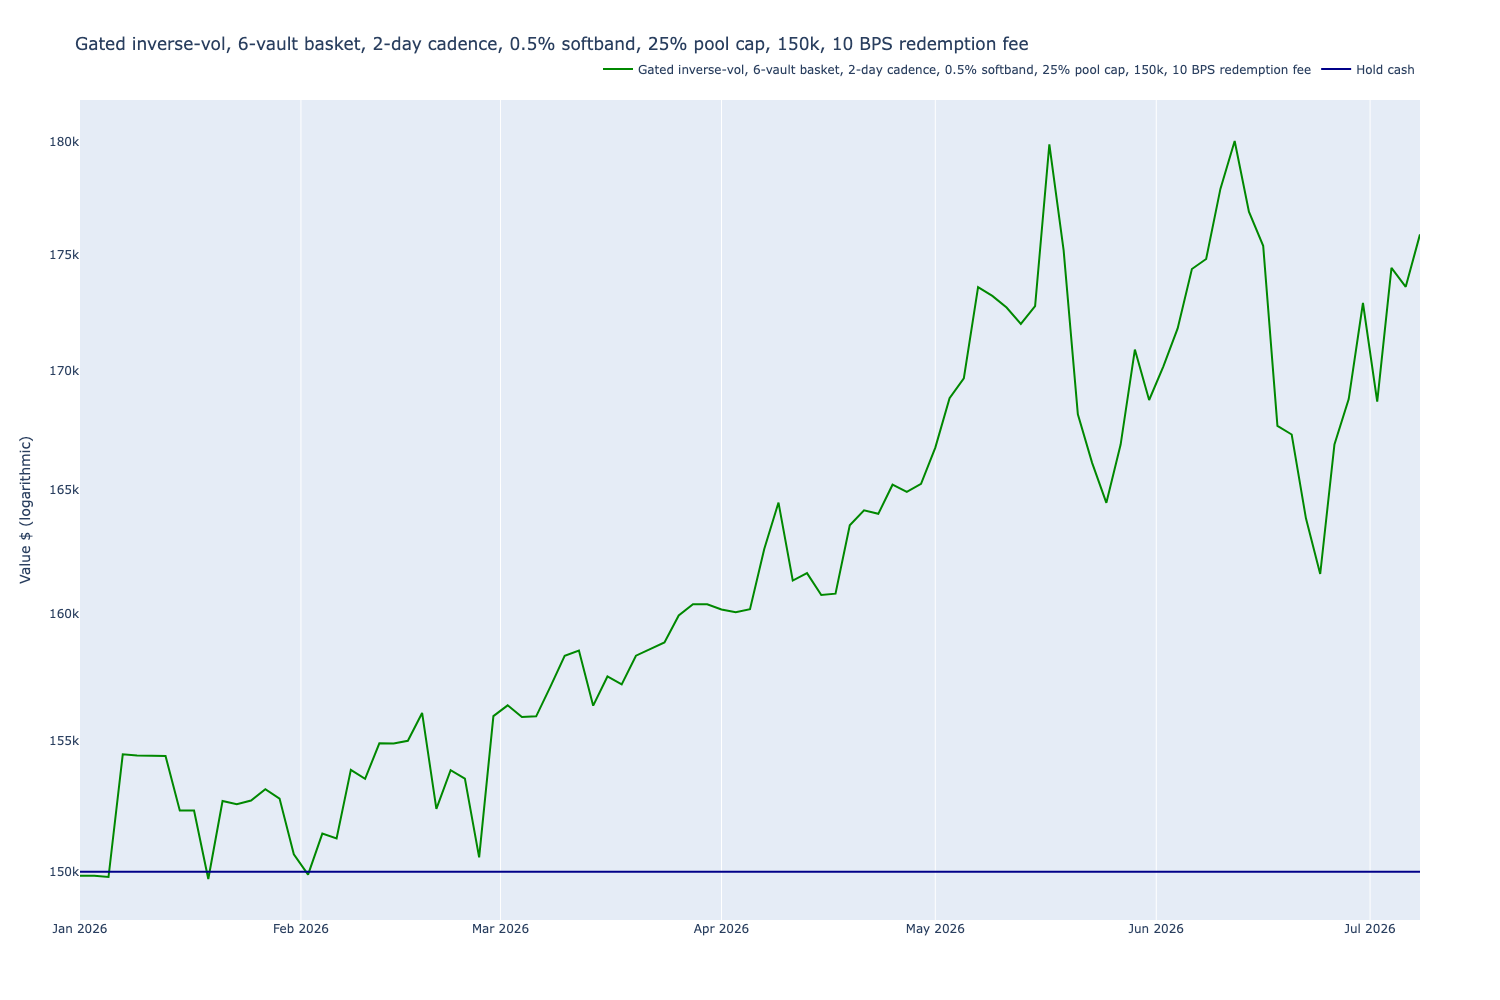

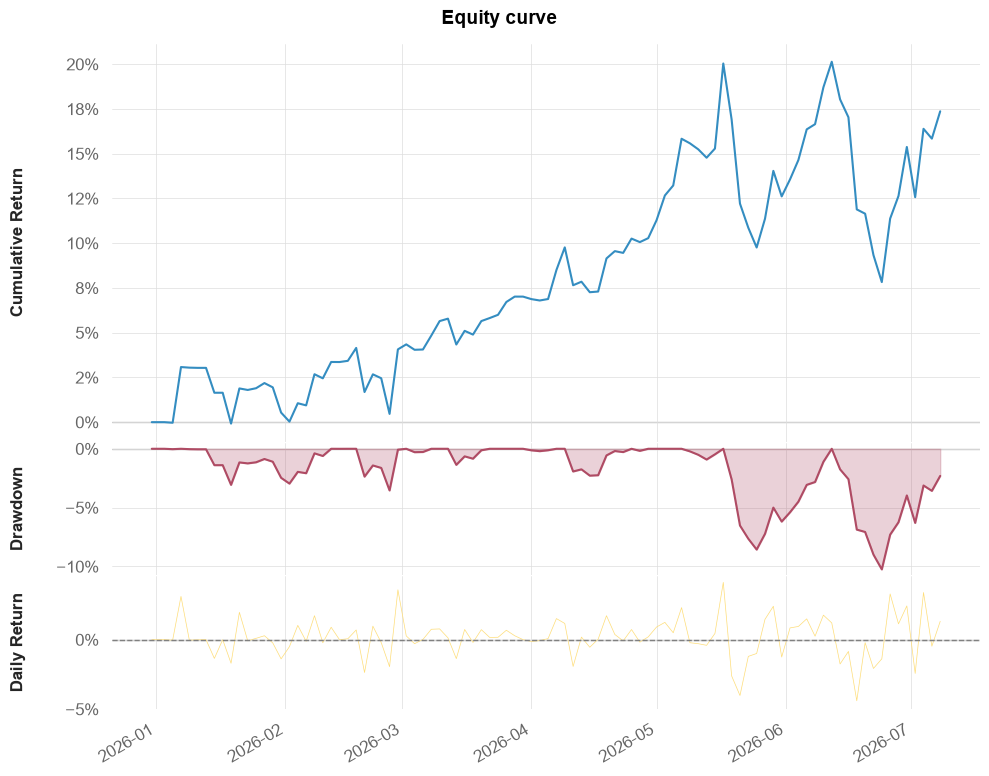

In [12]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

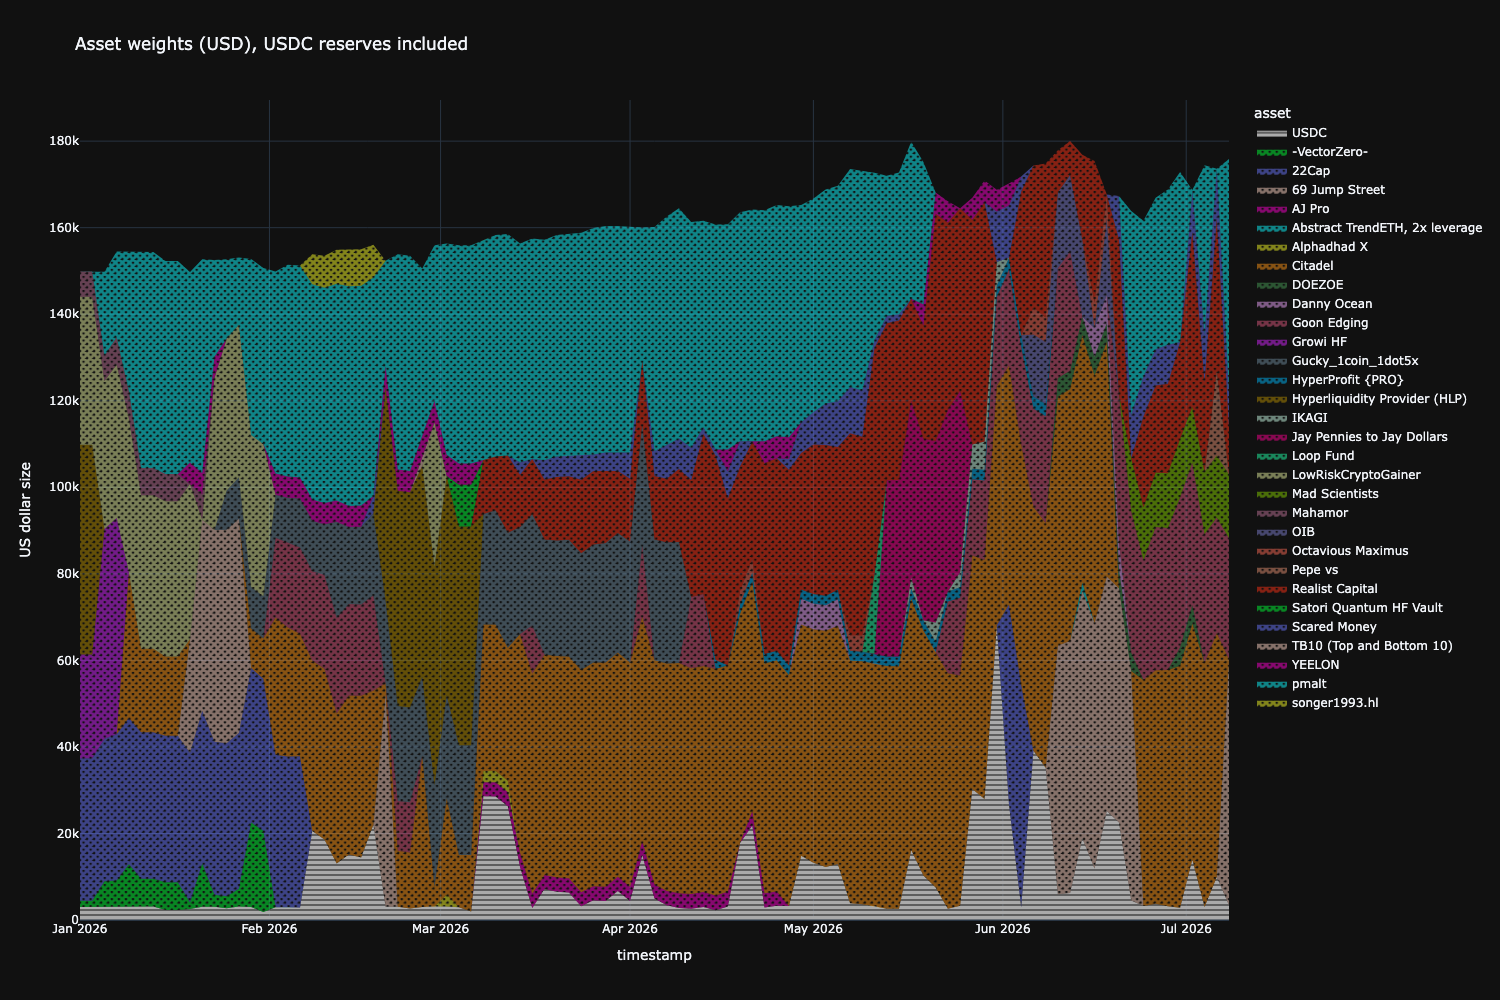

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-06-12,69 Jump Street,"$58,221.12",
Min position (excluding USDC),2026-01-01,-VectorZero-,"$1,444.94",
Mean position (excluding USDC),,,"$25,434.35",
Max position (excluding USDC),2026-05-31,Citadel,54.92%,
Min position (excluding USDC),2026-05-15,Scared Money,0.86%,
Mean position (excluding USDC),,,16.67%,
Max position (including USDC),2026-05-31,USDC,40.37%,
Min position (including USDC),2026-05-15,Scared Money,0.85%,
Mean position (including USDC),,,14.29%,


In [13]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

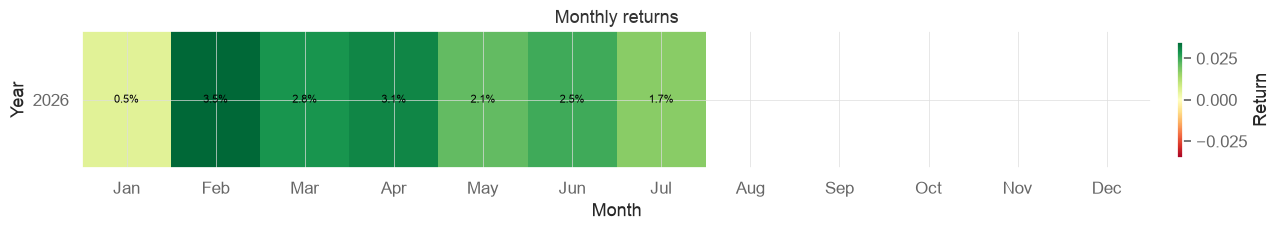

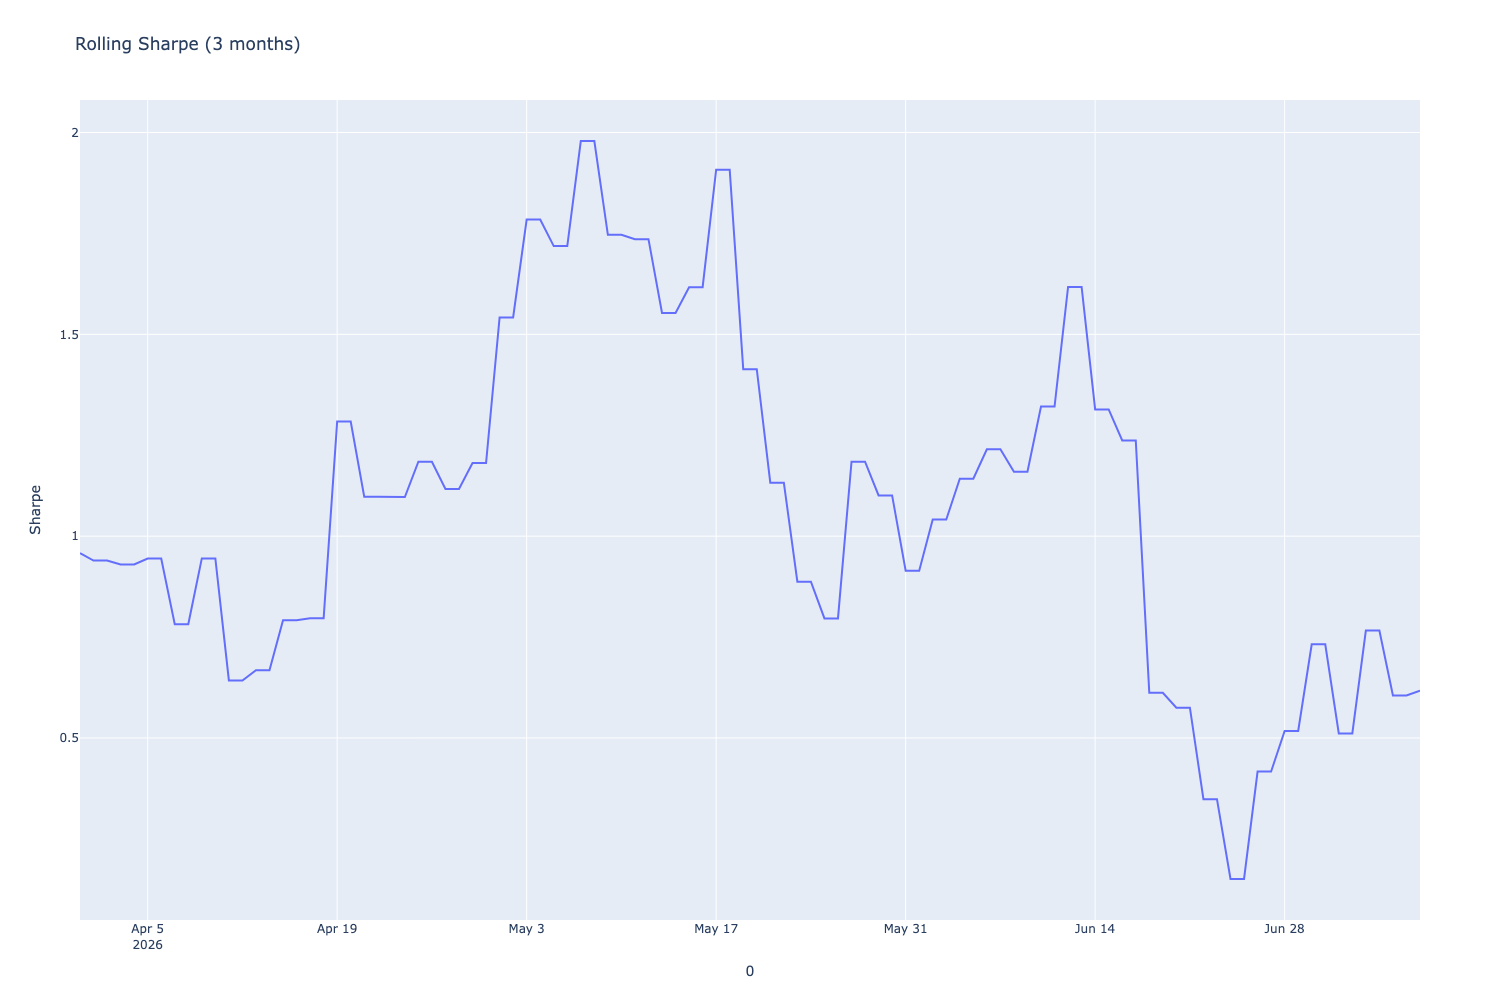

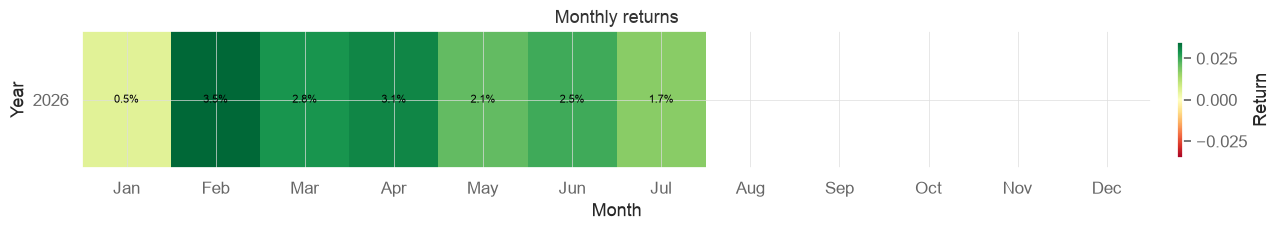

In [14]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [15]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0,0,0
Time in Market,0.49,0.98,0.98
Cumulative Return,0.17,-0.32,-0.45
CAGR﹪,0.36,-0.52,-0.68
Sharpe,1.67,-1.28,-1.43
Prob. Sharpe Ratio,0.88,0.18,0.15
Smart Sharpe,1.66,-1.27,-1.42
Sortino,2.56,-1.72,-1.93


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,9698.537632,Realist Ca,2026-06-24,NaT,8
1,6749.030283,pmalt,2026-01-05,2026-05-21,44
2,6698.548145,Scared Mon,2026-04-27,2026-05-17,8
3,4529.390098,Realist Ca,2026-03-08,2026-05-31,33
4,3430.410441,Goon Edgin,2026-05-23,2026-06-14,7
5,3056.407382,Goon Edgin,2026-02-02,2026-02-20,8
6,2964.274898,Growi HF,2026-01-01,2026-01-09,4
7,1317.267432,Scared Mon,2026-04-05,2026-04-21,6
8,839.053985,Gucky_1coi,2026-01-25,2026-04-11,21
9,833.529306,Citadel,2026-01-29,2026-06-20,50


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-3880.488484,songer1993,2026-02-08,2026-02-20,4
1,-3103.943099,Pepe vs,2026-07-06,2026-07-08,2
2,-2869.360557,Citadel,2026-01-09,2026-01-19,4
3,-2248.143391,Realist Ca,2026-06-20,2026-06-22,2
4,-2230.570246,-VectorZer,2026-01-01,2026-02-02,12
5,-1424.498776,Goon Edgin,2026-02-22,2026-02-26,3
6,-1208.110156,Realist Ca,2026-06-04,2026-06-18,8
7,-1098.656427,IKAGI,2026-05-21,2026-05-23,2


,token,value,vault,protocol,link
position_id,,,,,
64,Goon Edgin,27983.694373,Goon Edging,hyperliquid,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f
67,Mad Scient,14668.552234,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4
70,Realist Ca,11050.289018,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
72,Scared Mon,8124.522059,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
75,69 Jump St,56858.825504,69 Jump Street,hyperliquid,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802
76,pmalt,53774.357550,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,95.00
mean cash %,6.71
median cash %,2.09
max cash %,100.00
final-cycle cash %,5.64
mean deployment shortfall % of investable,3.81
cycles with shortfall > 10% of investable,15.00
mean signals pool-capped per cycle,3.29
mean signals concentration-capped per cycle,2.73
cycles where ALL selected signals were pool-capped,0.00


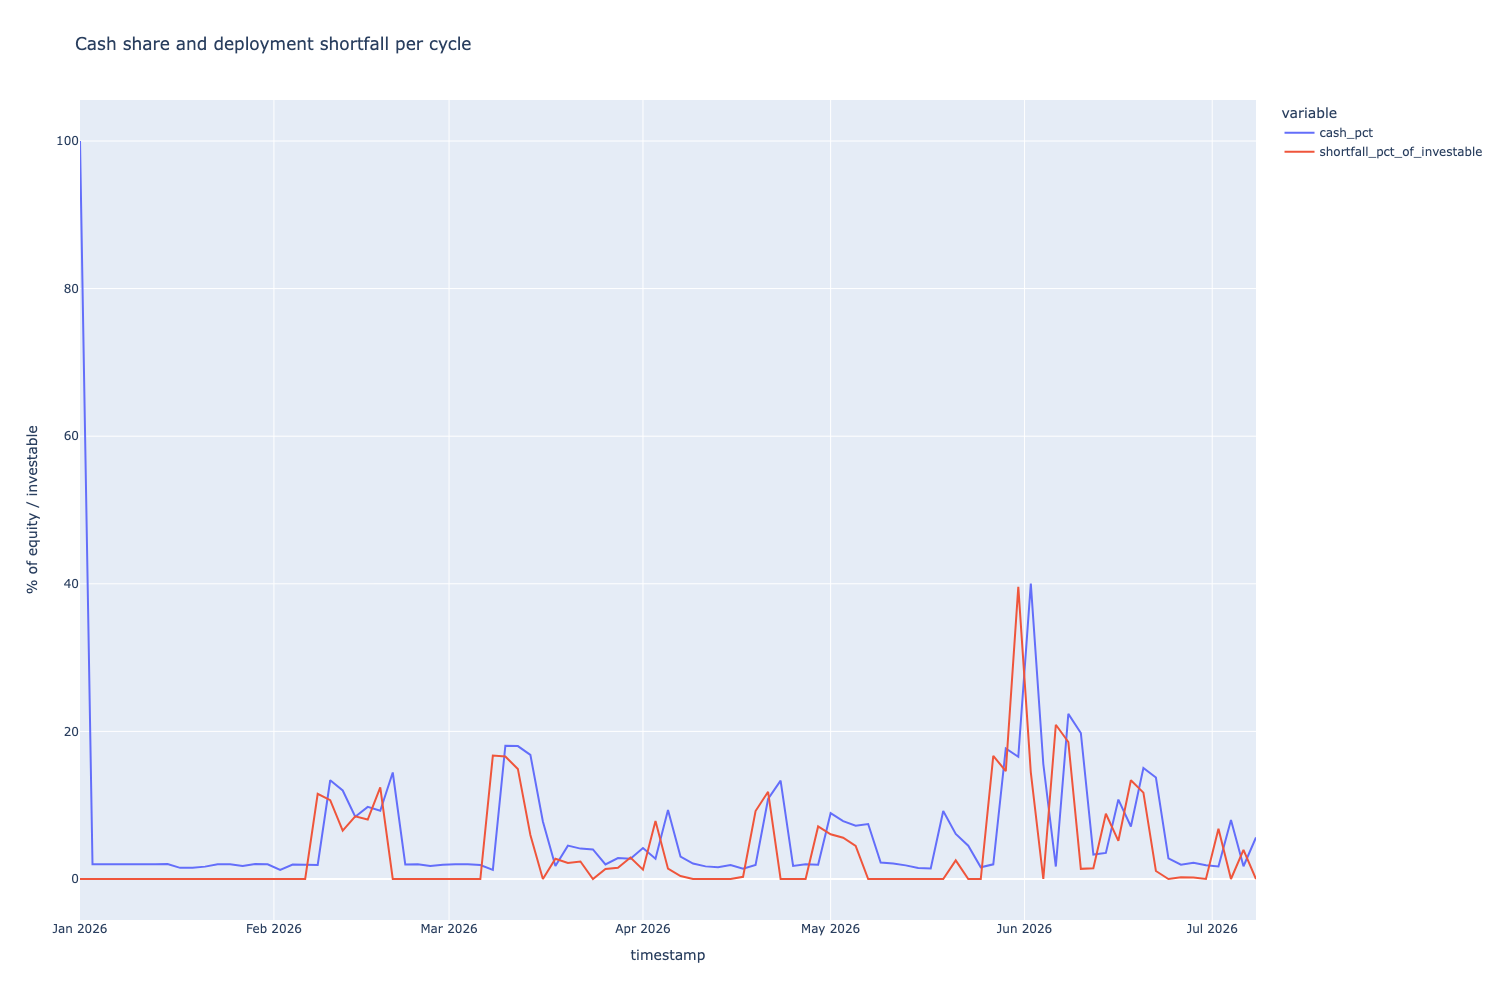

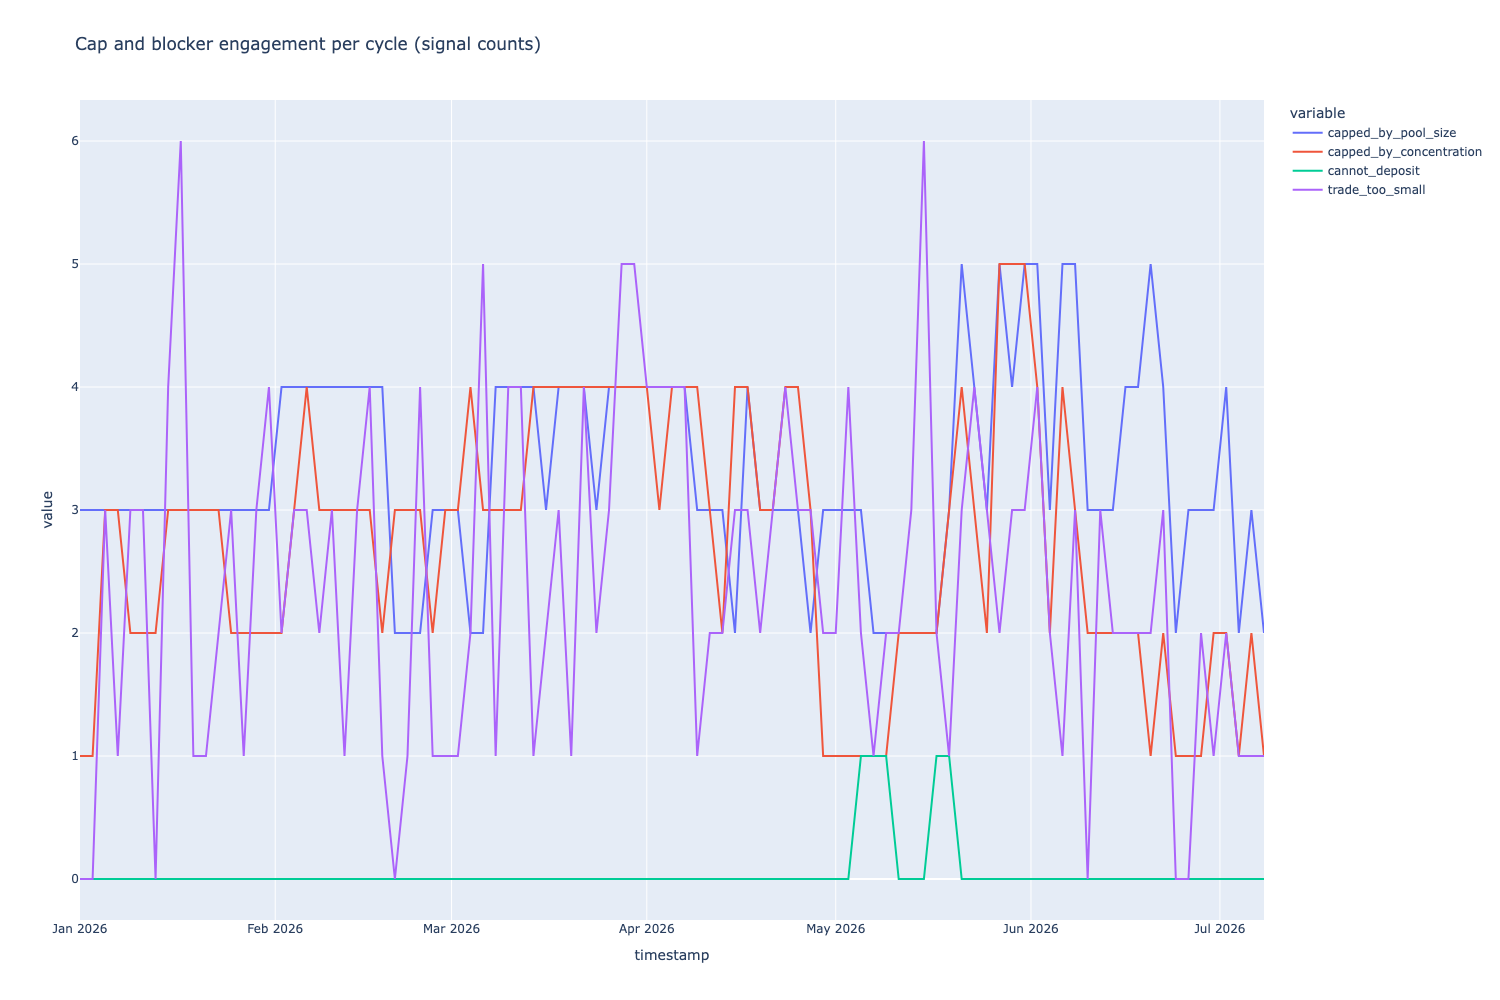

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-05-11,2.1,0,1,2,Citadel-USDC
2026-05-13,1.8,0,1,2,Jay
2026-05-15,1.5,0,1,2,Jay
2026-05-17,1.4,1,2,2,Jay
2026-05-19,9.2,1,2,3,YEELON-USDC
2026-05-21,6.1,0,2,5,YEELON-USDC
2026-05-23,4.5,0,2,4,YEELON-USDC
2026-05-25,1.6,0,2,3,Jay
2026-05-27,2.0,0,2,5,YEELON-USDC


In [16]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


In [17]:
# Shared analysis helpers used by every grid in this notebook.
#
# Kept in their own cell deliberately: earlier variants defined these inside a grid cell, and
# replacing that grid in the next variant silently removed them.
from tradeexecutor.analysis.weights import calculate_asset_weights, visualise_weights


def deployment_stats(state_) -> dict:
    """Cash, deployment shortfall and cap-binding counts for one run.

    `extract_allocation_df()` returns the raw per-cycle fields; `cash_pct` and the shortfall
    percentage are derived from them above rather than inside that function, so recompute here.
    """
    alloc = extract_allocation_df(state_)
    if not len(alloc):
        return {}
    cash_pct = alloc["cash"] / alloc["total_equity"] * 100
    shortfall_pct = (alloc["investable"] - alloc["accepted"]) / alloc["investable"] * 100
    return {
        "Mean cash %": float(cash_pct.mean()),
        "Deployment shortfall %": float(shortfall_pct.mean()),
        "Cycles >10% unplaced": int((shortfall_pct > 10).sum()),
        "Pool-capped per cycle": float(alloc["capped_by_pool_size"].mean()),
        "Concentration-capped per cycle": float(alloc["capped_by_concentration"].mean()),
    }


def weight_concentration_stats(weights_series: pd.Series) -> dict:
    """Largest weight and effective position count from an asset weight timeline.

    `calculate_asset_weights()` returns a (timestamp, asset) MultiIndex of USD values, so normalise
    within each timestamp before measuring concentration. Reserves are dropped: cash is not a
    position and would flatter the diversification measure exactly when the strategy fails to
    deploy.
    """
    frame = weights_series.unstack(level=1).fillna(0.0)
    for reserve in ("USDC", "USDT", "USDC.e", "USDT0"):
        if reserve in frame.columns:
            frame = frame.drop(columns=[reserve])
    totals = frame.sum(axis=1)
    frame = frame.loc[totals > 0]
    if not len(frame):
        return {}
    normalised = frame.div(frame.sum(axis=1), axis=0)
    herfindahl = (normalised ** 2).sum(axis=1)
    return {
        "Mean largest weight": float(normalised.max(axis=1).mean()),
        "Max largest weight": float(normalised.max(axis=1).max()),
        "Effective positions": float((1.0 / herfindahl).mean()),
        "Mean held": float((normalised > 0.005).sum(axis=1).mean()),
    }


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [18]:
#: Label derives from the configured cap - it was hardcoded to "15%" in the ancestor
#: notebooks, which silently mislabels any variant that changes the pool cap.
POOL_CAP_LABEL = f"Pool cap ({Parameters.per_position_cap_of_pool_pct:.0%} of TVL) USD"

final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        POOL_CAP_LABEL: last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df[POOL_CAP_LABEL].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (25% of TVL) USD
4,69 Jump St,56859.0,258067.0,64517.0
5,pmalt,53774.0,513987.0,128497.0
0,Goon Edgin,27984.0,108169.0,27042.0
1,Mad Scient,14669.0,59388.0,14847.0
2,Realist Ca,11050.0,485292.0,121323.0
3,Scared Mon,8125.0,50278.0,12569.0


Final cycle equity: 175,992 USD, cash: 9,919 USD (5.6%)
Investable (98% target): 172,472 USD, accepted by caps: 172,472 USD
Sum of pool caps across held vaults: 368,795 USD

Last cycle raw diagnostics:
Cycle: #95
Rebalanced: 👍
Open/about to open positions: 8
Max position value change: 56,915.74 USD
Rebalance threshold: 75.00 USD
Trades decided: 7
Pairs meeting inclusion criteria: 199
Pairs meeting TVL inclusion criteria: 202
Candidate signals created: 186
Selected survivor signals: 8
Candidates skipped for closed deposit window: 1
CAGR lookback days: 360
Sharpe lookback days: 180
CAGR weight (blend): 0.5
Total equity: 175,991.78 USD
Cash: 9,919.43 USD
Redeemable capital: 166,072.35 USD
Pending redemptions: 0.00 USD
Investable equity: 172,471.94 USD
Accepted investable equity: 172,471.94 USD
Allocated to signals: 172,471.94 USD
Discarded allocation because of lack of lit liquidity: 11,790.02 USD
Rebalance volume: 0.00 USD
Top signal pair: 69 Jump St-USDC
Top signal value: 95159.14968398

# Redemption fee verification and cost accounting

Verify the fee actually reached the executed sell prices, and total up what it cost.

Two sell paths exist and both must be checked:

- **Full closes** go through `PositionManager.close_position()`, which prices straight off
  `BacktestPricing.get_sell_price()`, so the fee lands as `share price x (1 - fee)`.
- **Partial reductions** of a Hypercore position go through `PositionManager.adjust_position()`,
  which overrides the pricing-model price with the position's *marked* price
  (trade-executor `7e673dc6`, so live partial redemptions size off the live implied share price).
  That marked price is itself produced by `BacktestValuationModel` from `get_sell_price()` at the
  same cycle timestamp, so the fee is still charged — but the trade's `planned_mid_price` is
  overwritten with the same value and can no longer be used to measure it.

The verification below is therefore independent of both paths: it compares each executed sell
price against the vault's own daily close (share price) at the time the trade was planned.


,Trades,Configured fee,Median implied fee,Mean implied fee,Within 1 BPS of configured
Sell type,,,,,
Full close,70,0.100%,0.100%,-1.439%,54.3%
Partial reduction,83,0.100%,0.100%,-0.530%,53.0%
All sells,153,0.100%,0.100%,-0.946%,53.6%


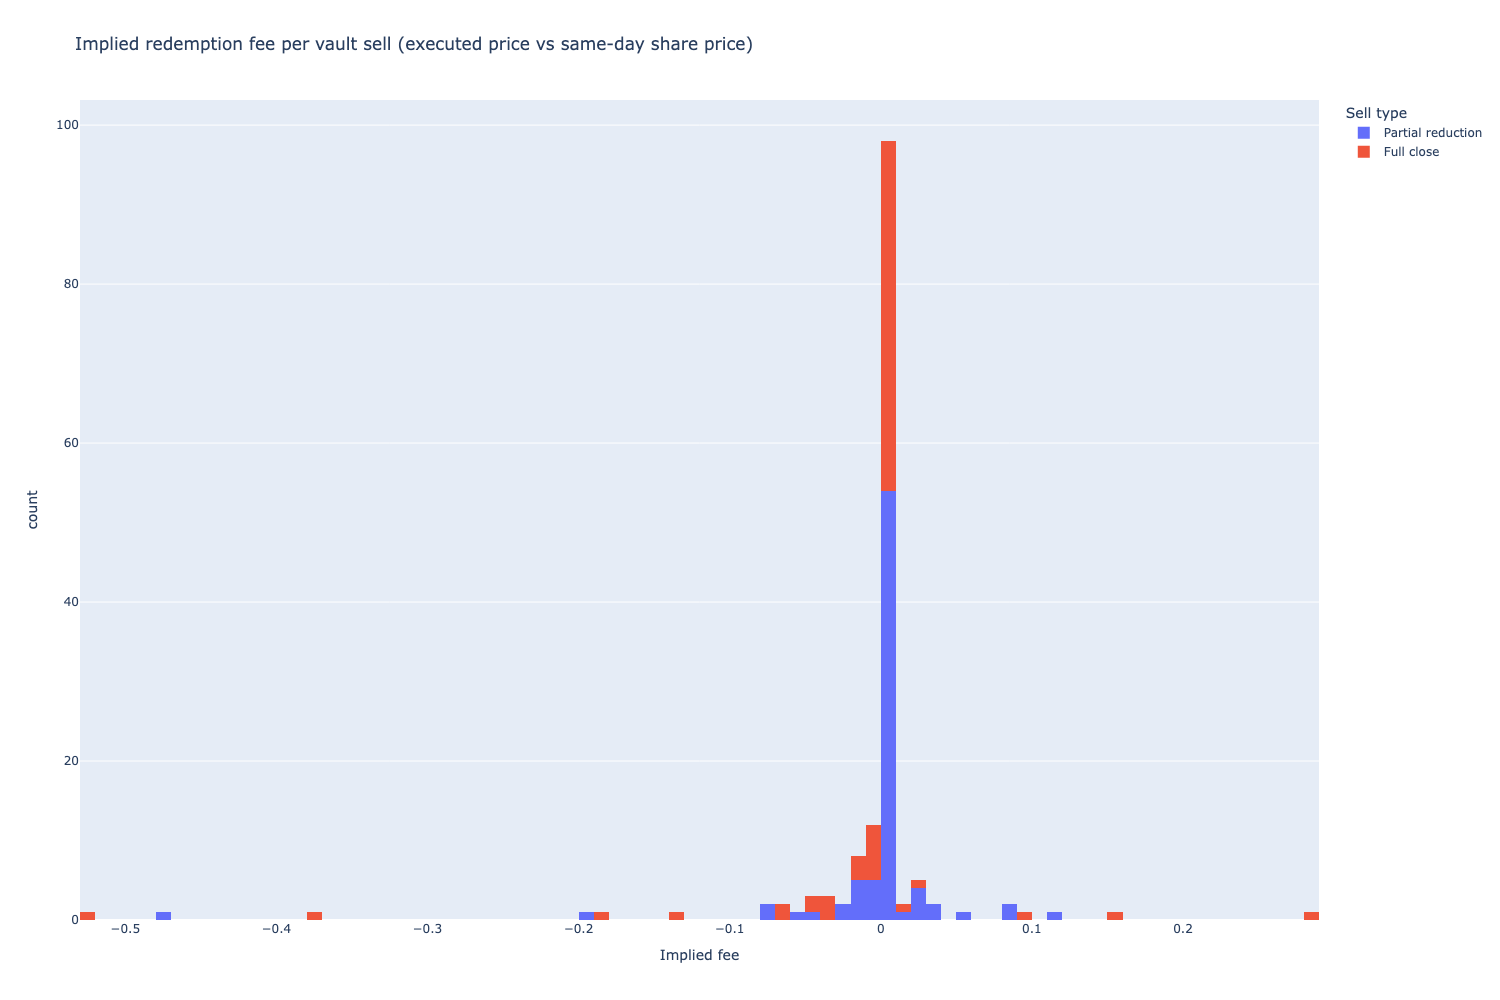

,Vault sell trades,Redemption volume USD,Redemption fee paid USD,Fee as % of initial capital,Fee as % of final equity,Redemption turnover x initial capital
0,153,"$1,779,907","$1,782",1.19%,1.01%,11.9x


,Sells,Proceeds USD,Fee paid USD
Vault,,,
Realist Ca,19,"$290,440",$290.73
pmalt,25,"$253,577",$253.83
Citadel,20,"$239,615",$239.86
69 Jump St,7,"$157,995",$158.15
Goon Edgin,13,"$115,539",$115.66
LowRiskCry,3,"$103,591",$103.69
Hyperliqui,3,"$100,134",$100.23
22Cap,2,"$86,257",$86.34
Scared Mon,16,"$69,900",$69.97


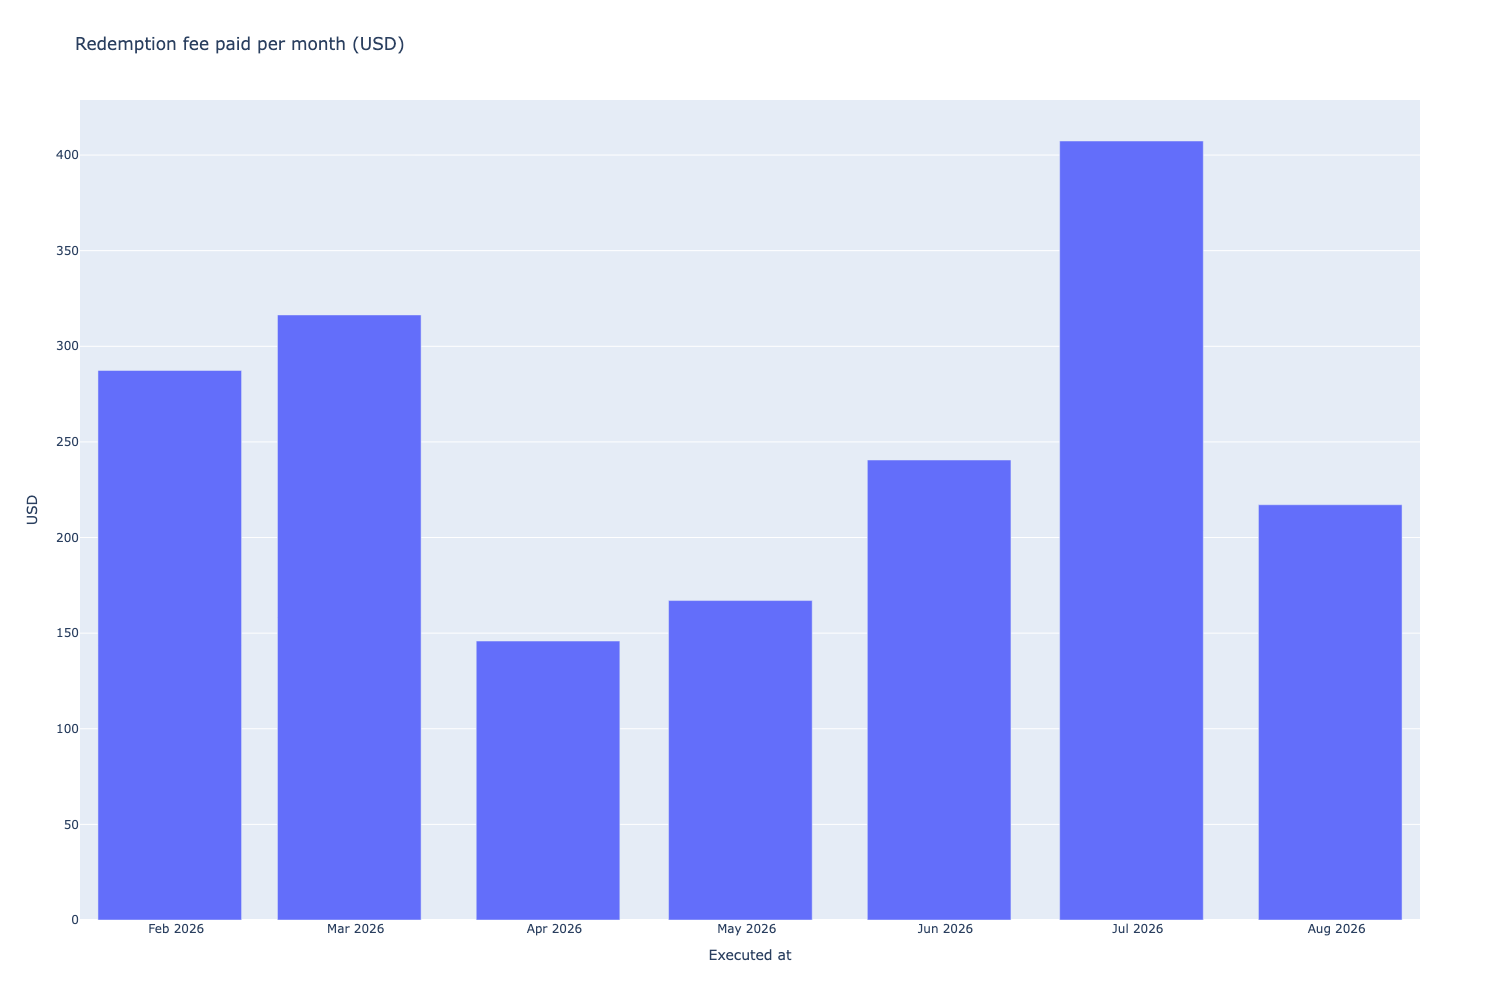

In [19]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        closes = candles.set_index('timestamp')['close'].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float('nan')


def build_vault_sell_df(state_, fee_: float) -> pd.DataFrame:
    """Every successful vault sell, with the fee implied by its executed price.

    :param fee_:
        Redemption fee configured for the run that produced ``state_``.
    """
    rows = []
    for trade in state_.portfolio.get_all_trades():
        if not trade.pair.is_vault():
            continue
        if not trade.is_sell() or not trade.is_success():
            continue
        share_price = get_vault_share_price(trade.pair, trade.opened_at)
        proceeds = abs(float(trade.executed_reserve or 0.0))
        rows.append({
            'Vault': trade.pair.base.token_symbol,
            'Planned at': trade.opened_at,
            'Executed at': trade.executed_at,
            'Sell type': 'Full close' if trade.closing else 'Partial reduction',
            'Share price': share_price,
            'Planned price': float(trade.planned_price),
            'Implied fee': float(1.0 - trade.planned_price / share_price) if share_price == share_price else float('nan'),
            'Proceeds USD': proceeds,
            'Fee paid USD': proceeds * fee_ / (1.0 - fee_) if fee_ else 0.0,
        })
    return pd.DataFrame(rows)


def summarise_implied_fees(df: pd.DataFrame, fee_: float) -> pd.DataFrame:
    """Implied-fee statistics, split by sell type."""
    rows = []
    for sell_type, group in list(df.groupby('Sell type')) + [('All sells', df)]:
        implied = group['Implied fee'].dropna()
        rows.append({
            'Sell type': sell_type,
            'Trades': len(group),
            'Configured fee': fee_,
            'Median implied fee': float(implied.median()),
            'Mean implied fee': float(implied.mean()),
            'Within 1 BPS of configured': float((implied.sub(fee_).abs() <= 0.0001).mean()),
        })
    return pd.DataFrame(rows).set_index('Sell type')


fee = Parameters.vault_redemption_fee
vault_sell_df = build_vault_sell_df(state, fee)

display(
    summarise_implied_fees(vault_sell_df, fee).style.format({
        'Configured fee': '{:.3%}',
        'Median implied fee': '{:.3%}',
        'Mean implied fee': '{:.3%}',
        'Within 1 BPS of configured': '{:.1%}',
    }).set_caption('Implied redemption fee by sell type')
)

fig = px.histogram(
    vault_sell_df,
    x='Implied fee',
    color='Sell type',
    nbins=120,
    title='Implied redemption fee per vault sell (executed price vs same-day share price)',
)
fig.show()

total_fee_usd = float(vault_sell_df['Fee paid USD'].sum())
total_proceeds_usd = float(vault_sell_df['Proceeds USD'].sum())
final_equity = float(equity.iloc[-1])

fee_summary_df = pd.DataFrame([{
    'Vault sell trades': len(vault_sell_df),
    'Redemption volume USD': total_proceeds_usd,
    'Redemption fee paid USD': total_fee_usd,
    'Fee as % of initial capital': total_fee_usd / Parameters.initial_cash,
    'Fee as % of final equity': total_fee_usd / final_equity,
    'Redemption turnover x initial capital': total_proceeds_usd / Parameters.initial_cash,
}])
display(fee_summary_df.style.format({
    'Redemption volume USD': '${:,.0f}',
    'Redemption fee paid USD': '${:,.0f}',
    'Fee as % of initial capital': '{:.2%}',
    'Fee as % of final equity': '{:.2%}',
    'Redemption turnover x initial capital': '{:.1f}x',
}))

fee_by_vault_df = vault_sell_df.groupby('Vault').agg(
    **{
        'Sells': ('Proceeds USD', 'size'),
        'Proceeds USD': ('Proceeds USD', 'sum'),
        'Fee paid USD': ('Fee paid USD', 'sum'),
    }
).sort_values('Fee paid USD', ascending=False)
display(
    fee_by_vault_df.head(15).style.format({
        'Proceeds USD': '${:,.0f}',
        'Fee paid USD': '${:,.2f}',
    }).set_caption('Redemption fee paid by vault (top 15)')
)

monthly_fee = vault_sell_df.set_index('Executed at')['Fee paid USD'].resample('1ME').sum()
fig = px.bar(monthly_fee, title='Redemption fee paid per month (USD)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='USD')
fig.show()


# A/B against the same run without the redemption fee

The honest way to price the fee is to re-run the identical strategy on the identical universe
with the fee switched off, rather than to compare against NB53's committed numbers (vault data
is refreshed between runs, so those numbers drift for reasons unrelated to the fee).

The only difference between the two runs below is the vault sell-side fee.


In [20]:
# Same universe, same indicators, same decide_trades - only the redemption fee differs.
apply_vault_redemption_fee(strategy_universe, 0.0)

baseline_result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, no redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

# Restore the configured fee so the rest of the notebook sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

baseline_state = baseline_result.state
baseline_equity = calculate_equity_curve(baseline_state)
baseline_returns = calculate_returns(baseline_equity)
baseline_positions = [p for p in baseline_state.portfolio.get_all_positions() if not p.is_credit_supply()]
print(f"Baseline (no fee) final equity: ${baseline_equity.iloc[-1]:,.0f}")
print(f"10 BPS fee       final equity: ${equity.iloc[-1]:,.0f}")


Baseline (no fee) final equity: $177,843
10 BPS fee       final equity: $175,880


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades
"Baseline, no redemption fee","$177,843",18.56%,39.18%,1.77,2.74,-10.05%,76,396
10 BPS redemption fee,"$175,880",17.25%,36.47%,1.67,2.56,-10.25%,76,397
Difference,"$-1,963",-1.31%,-2.71%,-0.10,-0.18,-0.20%,0,1


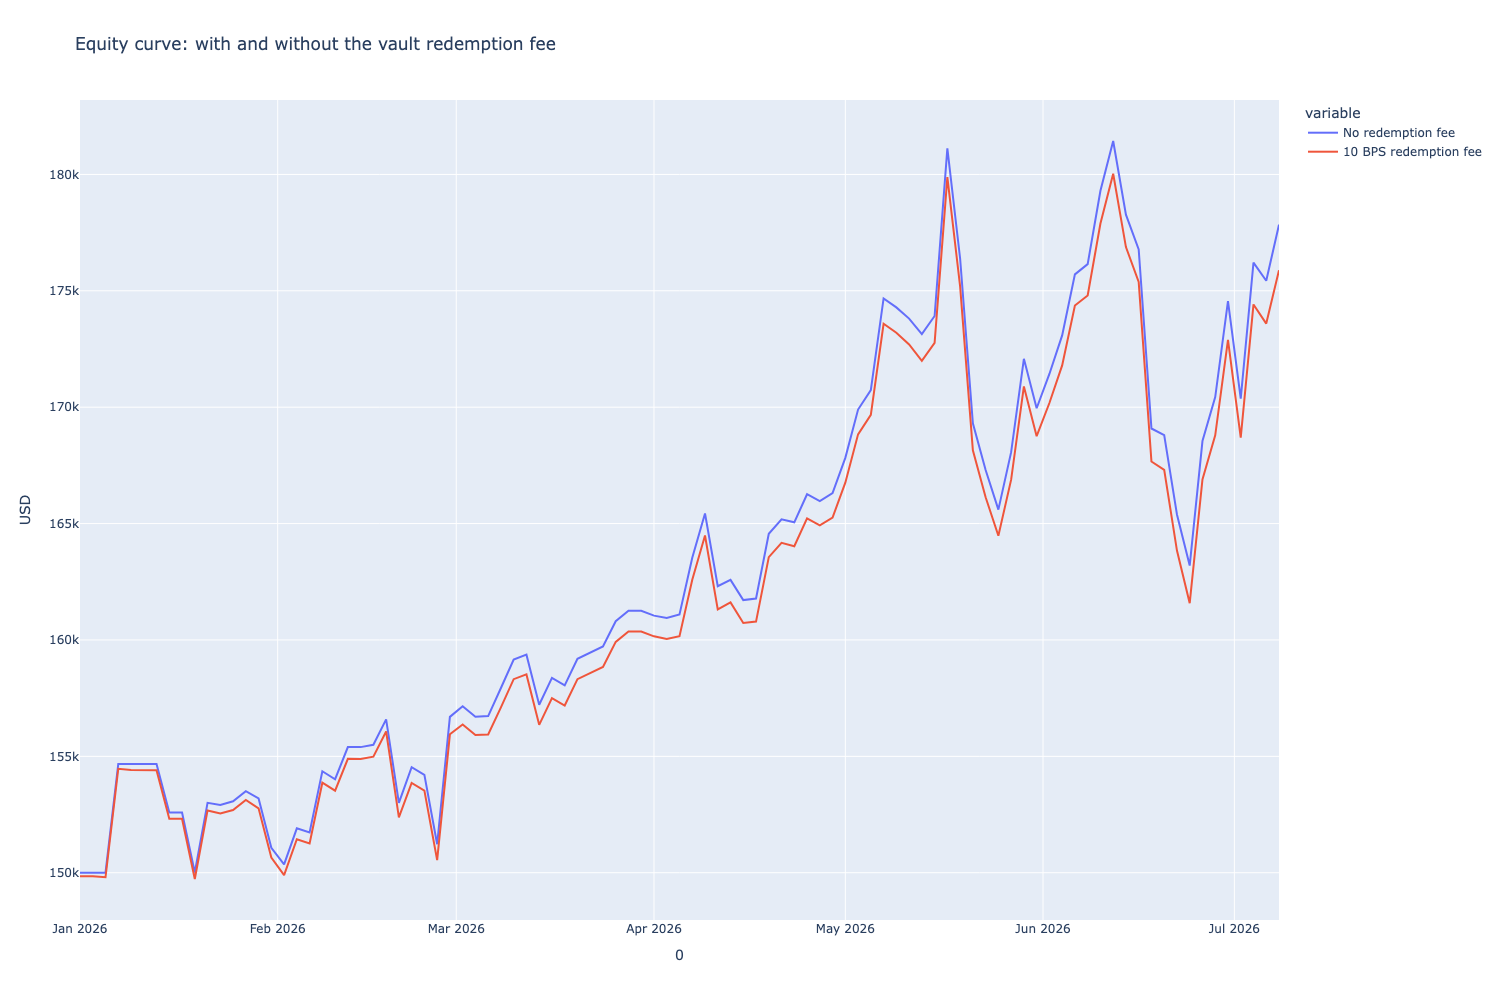

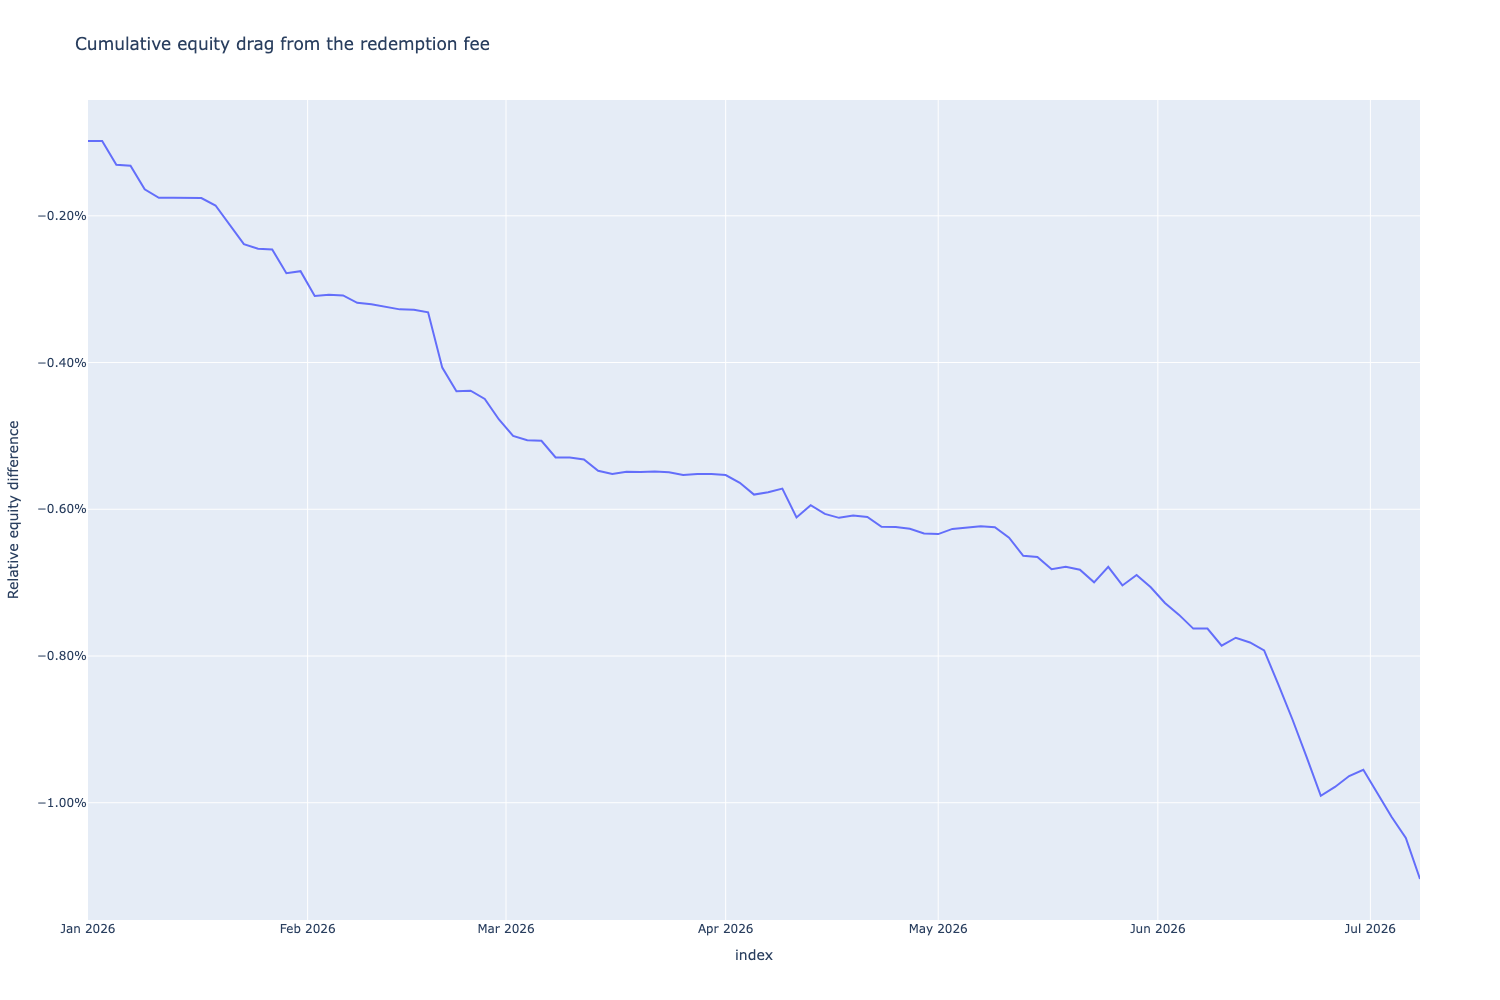

,Final equity difference USD,Final relative drag,Worst relative drag,Drag per year,Redemption fee paid USD (accounting)
0,"$-1,963",-1.10%,-1.10%,-2.14%,"$1,782"


In [21]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run.

    The equity curve is sampled **once per strategy cycle**, so a 2-day cadence produces one
    observation every 48 hours. Annualising that series with ``periods=365`` would overstate its
    Sharpe and Sortino by ``sqrt(2)`` against a daily-cadence run and make the two incomparable.
    Resample onto a common daily grid first - a 2-day step becomes one non-zero day and one zero
    day, which annualises correctly and matches the basis used in the robustness cell.

    Max drawdown is still measured on whatever grid the strategy values itself: a 2-day cadence
    cannot observe a trough that opens and closes inside one of its cycles, so its drawdown is
    measured over fewer marks than a daily cadence. That is a property of the schedule, not of
    this function.
    """
    return_series = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        'Run': label,
        'Final equity': float(equity_curve.iloc[-1]),
        'Cumulative return': float(equity_curve.iloc[-1] / Parameters.initial_cash - 1.0),
        'CAGR': float(calculate_cagr(return_series)),
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': float(calculate_max_drawdown(return_series)),
        'Positions': len(run_positions),
        'Trades': len(trades),
    }


comparison_df = pd.DataFrame([
    summarise_run('Baseline, no redemption fee', baseline_equity, baseline_state),
    summarise_run(f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee', equity, state),
]).set_index('Run')
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = 'Difference'
comparison_df = pd.concat([comparison_df, delta.to_frame().T])
display(comparison_df.style.format({
    'Final equity': '${:,.0f}',
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
    'Positions': '{:.0f}',
    'Trades': '{:.0f}',
}))

equity_comparison_df = pd.DataFrame({
    'No redemption fee': baseline_equity,
    f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee': equity,
}).ffill()
fig = px.line(equity_comparison_df, title='Equity curve: with and without the vault redemption fee')
fig.update_yaxes(title='USD')
fig.show()

drag = (equity_comparison_df.iloc[:, 1] / equity_comparison_df.iloc[:, 0] - 1.0)
fig = px.line(drag, title='Cumulative equity drag from the redemption fee')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='Relative equity difference', tickformat='.2%')
fig.show()

drag_df = pd.DataFrame([{
    'Final equity difference USD': float(equity.iloc[-1] - baseline_equity.iloc[-1]),
    'Final relative drag': float(drag.iloc[-1]),
    'Worst relative drag': float(drag.min()),
    'Drag per year': float(drag.iloc[-1]) / ((equity.index[-1] - equity.index[0]).days / 365.0),
    'Redemption fee paid USD (accounting)': total_fee_usd,
}])
display(drag_df.style.format({
    'Final equity difference USD': '${:,.0f}',
    'Final relative drag': '{:.2%}',
    'Worst relative drag': '{:.2%}',
    'Drag per year': '{:.2%}',
    'Redemption fee paid USD (accounting)': '${:,.0f}',
}))


In [22]:
# Control: the same implied-fee measurement on the no-fee baseline run.
#
# Hypercore partial reductions execute at the position's marked price, which is a cycle-start
# valuation and can differ from the same-day close for reasons that have nothing to do with the
# fee (stale marks, positions opened the same cycle, async settlement). The baseline run isolates
# that measurement noise: its implied fees must centre on zero, and the fee run must be the same
# distribution shifted by exactly the configured fee.
baseline_sell_df = build_vault_sell_df(baseline_state, 0.0)

control_df = pd.concat([
    summarise_implied_fees(baseline_sell_df, 0.0).assign(Run='Baseline, no fee'),
    summarise_implied_fees(vault_sell_df, Parameters.vault_redemption_fee).assign(Run='10 BPS fee'),
]).set_index('Run', append=True).reorder_levels(['Run', 'Sell type'])
display(control_df.style.format({
    'Configured fee': '{:.3%}',
    'Median implied fee': '{:.3%}',
    'Mean implied fee': '{:.3%}',
    'Within 1 BPS of configured': '{:.1%}',
}).set_caption('Implied fee measurement, fee run vs no-fee control'))

shift_df = pd.DataFrame([{
    'Median implied fee, baseline': float(baseline_sell_df['Implied fee'].median()),
    'Median implied fee, fee run': float(vault_sell_df['Implied fee'].median()),
    'Median shift': float(vault_sell_df['Implied fee'].median() - baseline_sell_df['Implied fee'].median()),
    'Mean shift': float(vault_sell_df['Implied fee'].mean() - baseline_sell_df['Implied fee'].mean()),
    'Configured fee': Parameters.vault_redemption_fee,
}])
display(shift_df.style.format('{:.3%}'))


,"Median implied fee, baseline","Median implied fee, fee run",Median shift,Mean shift,Configured fee
0,0.000%,0.100%,0.100%,0.101%,0.100%


# Vault price data coverage

Every metric above assumes the daily candle series carries a daily price. It does not, for the first
half of this window. The scanner behind `vault-price-history.parquet` sampled Hypercore vaults
**weekly** until mid-January 2026 and daily afterwards, and `load_partial_data()` forward-fills the
gaps, so a stale price is indistinguishable from an unchanged one inside the backtest.

This cell measures it from the raw parquet rather than taking it on trust.


Measuring coverage for 331 vault pairs in the strategy universe


Chains represented: [9999]


,days,days_with_data,mean_vaults_reporting,Coverage
timestamp,,,,
2026-01-01 00:00:00,25,17,84,68%
2026-02-01 00:00:00,28,28,186,100%
2026-03-01 00:00:00,31,31,241,100%
2026-04-01 00:00:00,30,30,256,100%
2026-05-01 00:00:00,31,31,266,100%
2026-06-01 00:00:00,30,30,281,100%
2026-07-01 00:00:00,9,9,286,100%


Days in window: 184   days with no price data at all: 8 (4%)
Median gap between data days before 2026-01-17: 7 days
Median gap between data days after  2026-01-17: 1 days
Daily-resolution sub-window: 2026-01-17 to 2026-07-10


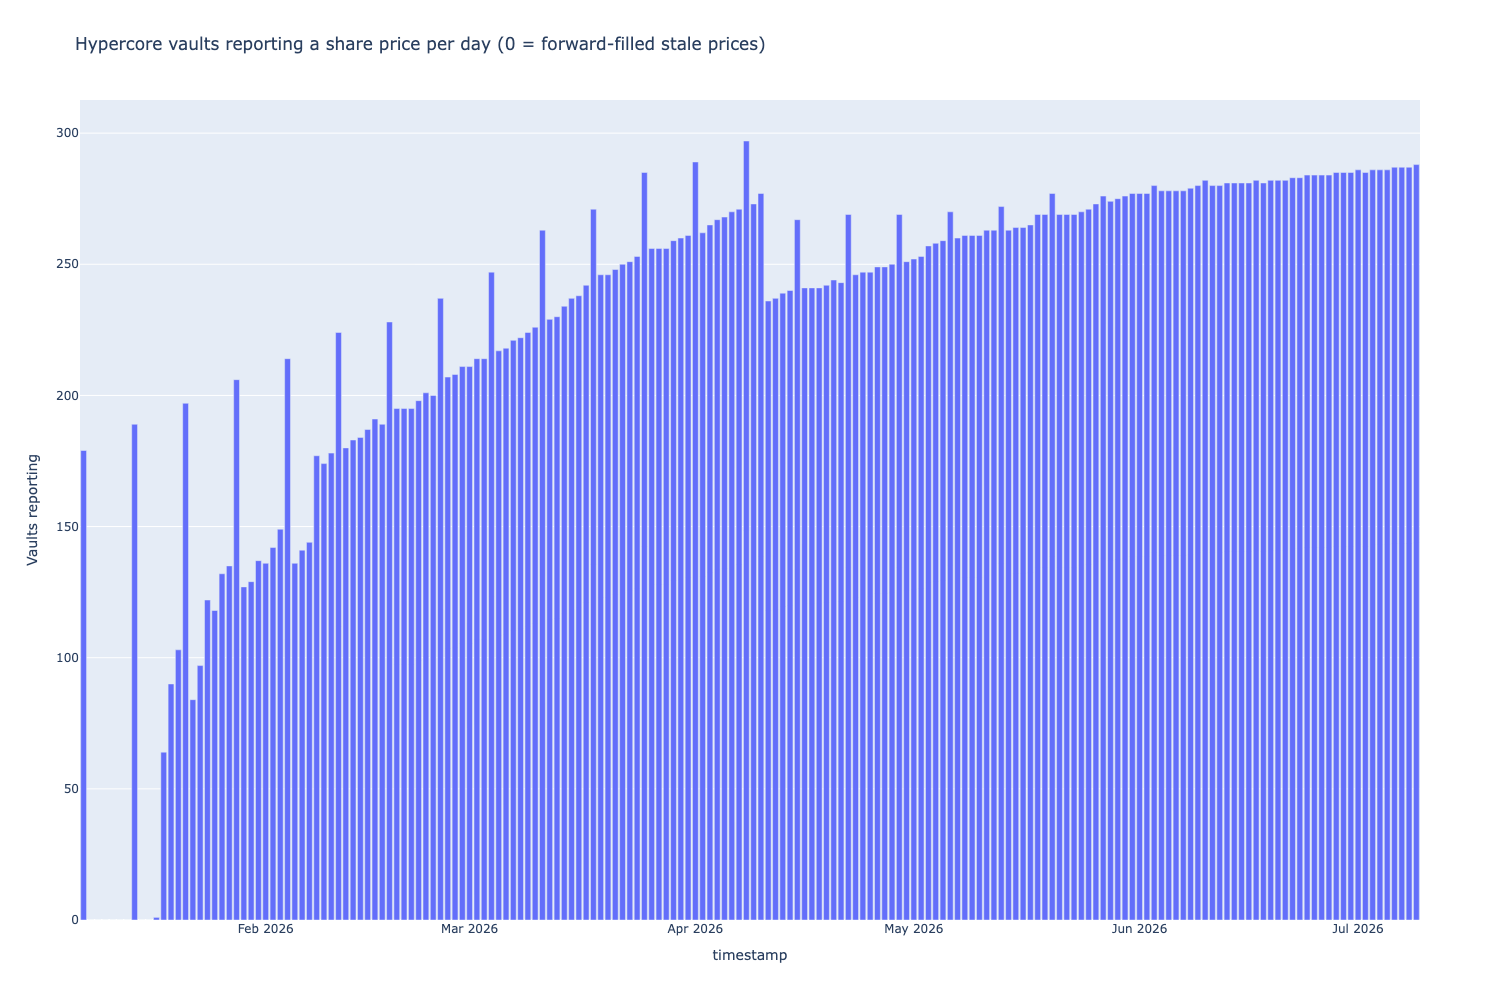

In [23]:
from pathlib import Path

VAULT_PRICE_PARQUET = Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-price-history.parquet"

# Measure the vaults this strategy actually trades, identified by address.
#
# Do NOT filter on `CHAIN_ID`: it is `ChainId.hyperliquid` (999, HyperEVM), while the tradeable
# vaults are Hypercore vaults on chain 9999. Filtering on 999 selects a different, fully covered
# set of vaults and reports 0% missing data.
traded_vault_addresses = {
    pair.pool_address.lower()
    for pair in strategy_universe.iterate_pairs()
    if pair.is_vault() and pair.pool_address
}
print(f"Measuring coverage for {len(traded_vault_addresses)} vault pairs in the strategy universe")

# `timestamp` is the parquet index, not a column.
coverage_raw = pd.read_parquet(VAULT_PRICE_PARQUET, columns=["chain", "address"]).reset_index()
coverage_raw = coverage_raw[coverage_raw["address"].str.lower().isin(traded_vault_addresses)]
coverage_raw = coverage_raw[
    (coverage_raw["timestamp"] >= Parameters.backtest_start)
    & (coverage_raw["timestamp"] < Parameters.backtest_end)
]
print(f"Chains represented: {sorted(coverage_raw['chain'].unique().tolist())}")

vaults_per_day = coverage_raw.set_index("timestamp").resample("1D")["address"].nunique()

coverage_by_month = vaults_per_day.groupby(pd.Grouper(freq="MS")).agg(
    days="size",
    days_with_data=lambda s: int((s > 0).sum()),
    mean_vaults_reporting="mean",
)
coverage_by_month["Coverage"] = coverage_by_month["days_with_data"] / coverage_by_month["days"]
display(coverage_by_month.style.format({
    "mean_vaults_reporting": "{:.0f}",
    "Coverage": "{:.0%}",
}).set_caption("Days on which any Hypercore vault reported a share price"))

data_days = vaults_per_day[vaults_per_day > 0].index

# The first date from which coverage stays daily for at least a fortnight.
DAILY_DATA_START = None
for offset in range(len(data_days) - 14):
    window_gaps = pd.Series(data_days[offset:offset + 14]).diff().dt.days.fillna(1)
    if (window_gaps == 1).all():
        DAILY_DATA_START = data_days[offset]
        break

assert DAILY_DATA_START is not None, "Never found a fortnight of continuous daily coverage"
assert DAILY_DATA_START > Parameters.backtest_start, (
    f"Daily coverage starts at the window start ({DAILY_DATA_START}), so the sub-window test below "
    f"would just repeat the full window - check that the address filter selected the traded vaults"
)

blank_days = int((vaults_per_day == 0).sum())
print(f"Days in window: {len(vaults_per_day)}   days with no price data at all: {blank_days} ({blank_days/len(vaults_per_day):.0%})")
print(f"Median gap between data days before {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days < DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Median gap between data days after  {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days >= DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Daily-resolution sub-window: {DAILY_DATA_START.date()} to {Parameters.backtest_end.date()}")

fig = px.bar(
    vaults_per_day,
    title="Hypercore vaults reporting a share price per day (0 = forward-filled stale prices)",
)
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Vaults reporting")
fig.show()


# Robustness diagnostics

In [24]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    # The equity curve is sampled once per strategy cycle, so on a 2-day cadence the "best day"
    # booked a two-day move. Measure each vault over the same span - comparing against yesterday's
    # close attributes only the final day and can show every holding flat while the portfolio jumps.
    equity_sample_days = pd.DatetimeIndex(equity.index).normalize()
    earlier_samples = equity_sample_days[equity_sample_days < best_day]
    span_start = earlier_samples[-1] if len(earlier_samples) else best_day - pd.Timedelta(days=1)
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index <= span_start].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return over the best step': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return over the best step',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return over the best step': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,17.37%,36.47%,1.67,2.56,-10.25%
Largest 5% profitable daily returns neutralised,5.24%,10.43%,0.65,0.89,-10.60%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2026-05-17 00:00:00,4.12%,2026-06-18 00:00:00,-4.40%,7.3%,0.06,5.66,3,3.35%


,Vault,Position opened,Position closed,Vault return over the best step,Realised profit USD,Curator-quarantined on best day
1,IKAGI,2026-05-17 00:00:00,2026-05-19 00:00:00,8.82%,$42,False
4,Realist Ca,2026-03-08 00:00:00,2026-05-31 00:00:00,2.35%,"$4,529",False
2,pmalt,2026-01-05 00:00:00,2026-05-21 00:00:00,1.40%,"$6,749",False
5,HyperProfi,2026-04-19 00:00:00,2026-06-10 00:00:00,0.69%,$532,False
3,Jay Pennie,2026-05-13 00:00:00,2026-05-27 00:00:00,0.01%,$46,False
6,Citadel,2026-01-29 00:00:00,2026-06-20 00:00:00,-0.00%,$834,False
0,Scared Mon,2026-04-27 00:00:00,2026-05-17 00:00:00,-8.14%,"$6,699",False


# The variants

Six ideas, five of them vetoes and one a re-ranking. The distinction is deliberate and is the main
lesson carried over from [NB78](78-research-curve-shape-and-ensemble-scoring.ipynb): re-ranking the
universe to avoid three bad vaults bought worse ones instead, at a cost nobody could measure. A veto
only ever subtracts, so what it removed can be counted exactly.

| Variant | Rule | Why | NB78 separation |
|---|---|---|---|
| **V1** | veto if downside share of risk `<` T | the headline signature, scale-free | 0.317 |
| **V2** | veto if down-day share `<` T | cruder, but immune to the degenerate zero case | 0.260 |
| **V3** | veto if lag-1 autocorrelation `>` T | standard smoothing / illiquidity proxy | 0.100 |
| **V4** | veto if return skew `>` T | jumpy upside | 0.067 |
| **V5** | veto if history days `<` T | NB77's best signal, promoted to a veto | 0.18 |
| **V6** | replace the Sharpe leg with Sortino | fixes the weak leg *inside* the score | Sharpe: 0.038 |

**The objective is Sharpe.** Every ladder is judged on it, with CAGR and drawdown reported
alongside.

## What would make a variant believable

A single winning threshold is not evidence. [NB77](77-research-loss-attribution-and-early-warning.ipynb)
found the momentum gate optimum was a **spike** - neighbouring thresholds were 10-22 pp of CAGR
worse - which is the signature of a value fitted to one window rather than a real effect.

So a variant is only interesting if it shows a **plateau**: several adjacent thresholds that all
beat the baseline. The results table reports the whole ladder for exactly this reason, and the
verdict cell scores plateau width rather than peak height.

Each run also reports **what the veto cost** - vaults dropped relative to baseline and the baseline
profit they carried - because NB78's failure was invisible in the headline metrics.


In [25]:
from tradeexecutor.backtest.backtest_execution import BacktestExecutionFailed


def _num(fn, default=float("nan")):
    try:
        value = fn()
    except Exception:
        return default
    return default if value is None else float(value)


def vault_pnl(run_state) -> dict:
    """Net P&L per vault symbol for one run."""
    out: dict[str, float] = {}
    for position in run_state.portfolio.get_all_positions():
        if position.is_credit_supply():
            continue
        realised = _num(position.get_realised_profit_usd, 0.0)
        unrealised = _num(position.get_unrealised_profit_usd, 0.0) if position.is_open() else 0.0
        out[position.pair.base.token_symbol] = out.get(position.pair.base.token_symbol, 0.0) + realised + unrealised
    return out


def run_variant(label: str, **overrides) -> dict:
    """One backtest with veto / selection overrides applied."""
    run_parameters = StrategyParameters.from_dict(dict(parameters))
    for key, value in overrides.items():
        run_parameters[key] = value
    try:
        run_result = run_backtest_inline(
            name=label,
            engine_version="0.5",
            decide_trades=decide_trades,
            indicator_combinations=indicator_data.indicator_combinations,
            cycle_duration=Parameters.cycle_duration,
            client=client,
            universe=strategy_universe,
            parameters=run_parameters,
            max_workers=1,
            start_at=Parameters.backtest_start,
            end_at=Parameters.backtest_end,
        )
    except BacktestExecutionFailed:
        print(f"  {label}: CRASHED")
        return {"Variant": label, "Crashed": True}

    run_state = run_result.state
    run_equity = calculate_equity_curve(run_state)
    pnl_by_vault = vault_pnl(run_state)
    pnls = list(pnl_by_vault.values())

    _pf = run_state.portfolio
    _realised = sum(float(x.get_realised_profit_usd() or 0) for x in _pf.get_all_positions())
    _unrealised = sum(float(x.get_unrealised_profit_usd() or 0)
                      for x in _pf.open_positions.values() if not x.is_credit_supply())
    _sells = [t for t in _pf.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
    _volume = sum(abs(float(t.executed_reserve or 0)) for t in _sells)
    _fee = _volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)
    _gap = (float(_pf.get_total_equity())
            - (Parameters.initial_cash + _realised + _unrealised)) / Parameters.initial_cash

    row = {"Variant": label, "Crashed": False}
    row.update(summarise_run(label, run_equity, run_state))
    row["Vaults held"] = len(pnl_by_vault)
    row["Gross loss USD"] = float(sum(v for v in pnls if v < 0))
    row["Unexplained %"] = _gap
    row["Coherent"] = abs(_gap) <= 0.01
    row["_pnl_by_vault"] = pnl_by_vault
    return row


baseline = run_variant("V0  baseline (no veto)")
BASELINE_PNL = baseline["_pnl_by_vault"]
BASELINE_SHARPE = baseline["Sharpe"]
print(f"Baseline: Sharpe {BASELINE_SHARPE:.3f}, CAGR {baseline['CAGR']:.2%}, "
      f"{baseline['Vaults held']} vaults, coherent={baseline['Coherent']}")


Baseline: Sharpe 1.670, CAGR 36.47%, 30 vaults, coherent=True


## Running every ladder

Roughly two dozen backtests. Each is a few seconds because the indicators are computed once and
shared.


In [26]:
VARIANTS = []

for threshold in (0.10, 0.20, 0.30, 0.40, 0.50):
    VARIANTS.append((f"V1  downside share < {threshold:.2f}",
                     dict(veto_indicator="downside_share", veto_threshold=threshold, veto_direction="below")))

for threshold in (0.02, 0.05, 0.08, 0.12, 0.15):
    VARIANTS.append((f"V2  down-day share < {threshold:.2f}",
                     dict(veto_indicator="down_day_share", veto_threshold=threshold, veto_direction="below")))

for threshold in (0.20, 0.30, 0.40, 0.50):
    VARIANTS.append((f"V3  lag-1 autocorr > {threshold:.2f}",
                     dict(veto_indicator="lag1_autocorr", veto_threshold=threshold, veto_direction="above")))

for threshold in (1.0, 1.5, 2.0, 3.0):
    VARIANTS.append((f"V4  skew > {threshold:.1f}",
                     dict(veto_indicator="return_skew", veto_threshold=threshold, veto_direction="above")))

for threshold in (180, 270, 360, 450):
    VARIANTS.append((f"V5  history < {threshold}d",
                     dict(veto_indicator="history_days", veto_threshold=float(threshold), veto_direction="below")))

VARIANTS.append(("V6  Sortino leg replaces Sharpe",
                 dict(selection_score_indicator="cagr_sortino_weight")))

rows = [baseline]
for label, overrides in VARIANTS:
    row = run_variant(label, **overrides)
    if not row.get("Crashed"):
        dropped = set(BASELINE_PNL) - set(row["_pnl_by_vault"])
        row["Vaults dropped"] = len(dropped)
        row["Baseline P&L dropped"] = float(sum(BASELINE_PNL[v] for v in dropped))
        row["Winners dropped USD"] = float(sum(BASELINE_PNL[v] for v in dropped if BASELINE_PNL[v] > 0))
        row["Losers dropped USD"] = float(sum(BASELINE_PNL[v] for v in dropped if BASELINE_PNL[v] < 0))
        row["Sharpe vs baseline"] = row["Sharpe"] - BASELINE_SHARPE
        print(f"  {label}: Sharpe {row['Sharpe']:.3f} ({row['Sharpe vs baseline']:+.3f}), "
              f"dropped {len(dropped)} vaults worth ${row['Baseline P&L dropped']:,.0f}")
    rows.append(row)

results_df = pd.DataFrame(rows).drop(columns=["_pnl_by_vault"]).set_index("Variant")
DISPLAY_COLS = ["Sharpe", "Sharpe vs baseline", "CAGR", "Max drawdown", "Sortino",
                "Vaults held", "Vaults dropped", "Winners dropped USD", "Losers dropped USD",
                "Gross loss USD", "Unexplained %", "Coherent"]
display(
    results_df[[c for c in DISPLAY_COLS if c in results_df.columns]]
    .style.format({
        "Sharpe": "{:.3f}", "Sharpe vs baseline": "{:+.3f}", "CAGR": "{:.2%}",
        "Max drawdown": "{:.2%}", "Sortino": "{:.2f}",
        "Winners dropped USD": "${:,.0f}", "Losers dropped USD": "${:,.0f}",
        "Gross loss USD": "${:,.0f}", "Unexplained %": "{:+.2%}",
    }, na_rep="-")
    .set_caption("All variants, ranked as run. Objective is Sharpe.")
)


  V1  downside share < 0.10: Sharpe 1.045 (-0.624), dropped 2 vaults worth $-3,152


  V1  downside share < 0.20: Sharpe 0.621 (-1.049), dropped 2 vaults worth $-3,152


  V1  downside share < 0.30: Sharpe 0.741 (-0.929), dropped 2 vaults worth $-3,152


  V1  downside share < 0.40: Sharpe 0.747 (-0.923), dropped 3 vaults worth $-7,032


  V1  downside share < 0.50: Sharpe 1.317 (-0.353), dropped 3 vaults worth $-7,032


...

  V5  history < 270d: Sharpe 1.670 (+0.000), dropped 0 vaults worth $0


  V5  history < 360d: Sharpe 1.670 (+0.000), dropped 0 vaults worth $0


  V5  history < 450d: Sharpe -0.634 (-2.303), dropped 12 vaults worth $-8,072


  V6  Sortino leg replaces Sharpe: Sharpe 1.663 (-0.007), dropped 5 vaults worth $-6,769


,Sharpe,Sharpe vs baseline,CAGR,Max drawdown,Sortino,Vaults held,Vaults dropped,Winners dropped USD,Losers dropped USD,Gross loss USD,Unexplained %,Coherent
Variant,,,,,,,,,,,,
V0 baseline (no veto),1.670,-,36.47%,-10.25%,2.56,30,-,-,-,"$-15,323",-0.00%,True
V1 downside share < 0.10,1.045,-0.624,21.52%,-14.21%,1.56,30,2.000000,$0,"$-3,152","$-17,770",-0.00%,True
V1 downside share < 0.20,0.621,-1.049,12.36%,-17.61%,0.87,30,2.000000,$0,"$-3,152","$-18,284",+0.00%,True
V1 downside share < 0.30,0.741,-0.929,14.61%,-14.71%,1.10,32,2.000000,$0,"$-3,152","$-22,183",+0.00%,True
V1 downside share < 0.40,0.747,-0.923,12.61%,-10.39%,1.14,33,3.000000,$0,"$-7,032","$-16,816",-0.00%,True
V1 downside share < 0.50,1.317,-0.353,25.25%,-9.83%,2.14,35,3.000000,$0,"$-7,032","$-17,673",+0.00%,True
V2 down-day share < 0.02,1.436,-0.234,29.50%,-10.44%,2.15,32,1.000000,$0,"$-3,104","$-12,445",+0.00%,True
V2 down-day share < 0.05,1.157,-0.512,23.04%,-10.62%,1.70,34,2.000000,$0,"$-3,111","$-14,688",+0.00%,True
V2 down-day share < 0.08,-0.385,-2.054,-11.17%,-15.50%,-0.47,36,7.000000,"$3,031","$-7,074","$-34,855",+0.00%,True


## Verdict: plateau, not peak

A variant earns belief only if **several adjacent thresholds** beat the baseline. One winner
surrounded by losers is the NB64/NB77 spike pattern and should be discarded regardless of how good
the peak looks.


In [27]:
sound = results_df[(~results_df["Crashed"].astype(bool)) & (results_df.index != "V0  baseline (no veto)")]

verdict_rows = []
for family, prefix in [("V1 downside share", "V1"), ("V2 down-day share", "V2"),
                       ("V3 lag-1 autocorr", "V3"), ("V4 skew", "V4"),
                       ("V5 history", "V5"), ("V6 Sortino leg", "V6")]:
    subset = sound[sound.index.str.startswith(prefix)]
    if subset.empty:
        continue
    beats = subset[subset["Sharpe"] > BASELINE_SHARPE]
    verdict_rows.append({
        "Family": family,
        "Thresholds tried": len(subset),
        "Beating baseline": len(beats),
        "Best Sharpe": float(subset["Sharpe"].max()),
        "Best delta": float(subset["Sharpe"].max() - BASELINE_SHARPE),
        "Median delta": float((subset["Sharpe"] - BASELINE_SHARPE).median()),
        "All coherent": bool(subset["Coherent"].all()),
    })

verdict_df = pd.DataFrame(verdict_rows).set_index("Family").sort_values("Best delta", ascending=False)
display(
    verdict_df.style.format({
        "Best Sharpe": "{:.3f}", "Best delta": "{:+.3f}", "Median delta": "{:+.3f}",
    }).set_caption(f"Plateau test. Baseline Sharpe {BASELINE_SHARPE:.3f}")
)

print()
for row in verdict_df.reset_index().to_dict("records"):
    if row["Beating baseline"] == 0:
        print(f"{row['Family']}: no threshold beats baseline - rejected")
    elif row["Beating baseline"] == 1:
        print(f"{row['Family']}: exactly ONE threshold beats baseline ({row['Best delta']:+.3f}) "
              f"- spike, not plateau. Treat as fitted.")
    else:
        print(f"{row['Family']}: {row['Beating baseline']} of {row['Thresholds tried']} thresholds beat "
              f"baseline, median {row['Median delta']:+.3f} - PLATEAU, worth pursuing")


,Thresholds tried,Beating baseline,Best Sharpe,Best delta,Median delta,All coherent
Family,,,,,,
V4 skew,4,1,1.712,+0.042,-1.230,True
V5 history,4,0,1.670,+0.000,+0.000,True
V6 Sortino leg,1,0,1.663,-0.007,-0.007,True
V2 down-day share,5,0,1.436,-0.234,-1.198,True
V1 downside share,5,0,1.317,-0.353,-0.923,True
V3 lag-1 autocorr,4,0,1.296,-0.374,-0.742,True



V4 skew: exactly ONE threshold beats baseline (+0.042) - spike, not plateau. Treat as fitted.
V5 history: no threshold beats baseline - rejected
V6 Sortino leg: no threshold beats baseline - rejected
V2 down-day share: no threshold beats baseline - rejected
V1 downside share: no threshold beats baseline - rejected
V3 lag-1 autocorr: no threshold beats baseline - rejected
